# Imports

In [1]:
import argparse
from urllib.parse import urljoin

import requests
from bs4 import BeautifulSoup

import os
import sys
import csv
import time
import random
import heapq, re, json
from typing import List, Tuple, Set, Iterable, Optional

from letterboxdpy import user as lb_user
from letterboxdpy.utils.utils_file import (
    build_path,
    check_and_create_dirs,
    save_json,
    build_click_url,
)

import json
import os
import pickle
import logging
from pathlib import Path
from typing import Dict, List, Optional

from collections import defaultdict
from scipy.stats import mannwhitneyu

import networkx as nx

import argparse
import csv
import logging
import re
import time
from pathlib import Path

from letterboxdpy.movie import Movie

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from collections import Counter
from matplotlib.patches import Patch
import warnings
from typing import Iterable, Dict, Tuple, Optional, Union
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS

# Part 0: Data Acquisition
For our project's dataset we have chosen the popular movie focused social media site Letterboxd.
- **Remark:** These codes scrape the data with a different kind of data structure.

## Generating Seed
For our project we have decided on the following:
- We will start with top 10 users of Letterboxd. (All-time popularity: https://letterboxd.com/members/popular/)
- We will increase the network by adding the outgoing-edges' nodes (following) to a priority-queue and always adding the next node with the most followers.

### Data and Stats

HERE

### Some Starting Parameters

In [ ]:
BASE = "https://letterboxd.com/"
HEADERS = {
    # Be a good citizen: identify yourself (put your own contact if you like)
    "User-Agent": "letterboxd-research/1.0 (+support@example.com)"
}

# Known routes for the Popular Members views
SORT_PATHS = {
    "all-time": "members/popular/",
    "week":     "members/popular/this/week/",
    "month":    "members/popular/this/month/",
    "year":     "members/popular/this/year/",
}

### Some Helper Functions

In [ ]:
# A random sleep to be polite with scraping on Letterboxd
def sleep_polite(low=0.8, high=1.6):
    time.sleep(random.uniform(low, high))

# Get url
def get(url, max_retries=6, timeout=20):
    """GET with retry/backoff on 429/5xx."""
    for attempt in range(max_retries):
        try:
            r = requests.get(url, headers=HEADERS, timeout=timeout)
        except requests.RequestException:
            # Network hiccup → small backoff
            time.sleep(min(8, 2**attempt) + random.random())
            continue

        if r.status_code in (429, 502, 503, 504):
            # Server stressed or rate-limiting → exponential backoff
            time.sleep(min(16, 2**attempt) + random.random())
            continue

        r.raise_for_status()
        return r
    # Final try raises if still failing
    r.raise_for_status()

# Check whether a link looks like a profile
def looks_like_profile_href(href: str) -> bool:
    """
    Accept only '/username/' (exactly two slashes, trailing slash).
    Filters out '/film/...', '/members/...', etc.
    """
    return (
        isinstance(href, str)
        and href.startswith("/")
        and href.endswith("/")
        and href.count("/") == 2
        and not href.startswith("/film/")
        and not href.startswith("/list/")
        and not href.startswith("/journal/")
        and not href.startswith("/members/")
        and not href.startswith("/crew/")
        and not href.startswith("/news/")
    )

def extract_usernames(soup: BeautifulSoup):
    """
    Grab profile links from member cards. Prefer h3 → a,
    fall back to any <a> that matches '/username/'.
    """
    usernames = []

    # Primary: member cards often have <h3><a href="/user/">
    for a in soup.select("h3 a[href]"):
        href = a.get("href", "")
        if looks_like_profile_href(href):
            usernames.append(href.strip("/"))

    # Fallback: scan all anchors (keeps order; dedup later)
    if not usernames:
        for a in soup.select("a[href]"):
            href = a.get("href", "")
            if looks_like_profile_href(href):
                usernames.append(href.strip("/"))

    # Keep order, drop dups
    seen, ordered = set(), []
    for u in usernames:
        if u not in seen:
            seen.add(u)
            ordered.append(u)
    return ordered

def iterate_popular_usernames(period="all-time", max_users=50, max_pages=20):
    """
    Yield usernames from the Popular Members pages until max_users collected.
    """
    path = SORT_PATHS.get(period, SORT_PATHS["all-time"])
    base = urljoin(BASE, path)

    page = 1
    collected = []
    while len(collected) < max_users and page <= max_pages:
        url = base if page == 1 else urljoin(base, f"page/{page}/")
        resp = get(url)
        soup = BeautifulSoup(resp.text, "html.parser")

        batch = extract_usernames(soup)
        # Stop if the page structure changed or we exhausted
        if not batch:
            break

        # Append new names only
        for u in batch:
            if u not in collected:
                collected.append(u)
                if len(collected) >= max_users:
                    break

        page += 1
        sleep_polite()

    return collected[:max_users]

# Output the seed.csv file
def write_seed_csv(usernames, out_path="seed.csv"):
    with open(out_path, "w", newline="", encoding="utf-8") as f:
        w = csv.writer(f)
        w.writerow(["username", "profile_url"])
        for u in usernames:
            w.writerow([u, urljoin(BASE, f"{u}/")])

def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--period", choices=["all-time", "week", "month", "year"],
                    default="all-time", help="Popularity period to scrape")
    ap.add_argument("--max", type=int, default=10,
                    help="How many usernames to collect")
    ap.add_argument("--out", type=str, default="seed.csv",
                    help="Output CSV path")
    args = ap.parse_args()

    users = iterate_popular_usernames(period=args.period, max_users=args.max)
    write_seed_csv(users, args.out)
    print(f"Wrote {len(users)} usernames to {args.out}")

if __name__ == "__main__":
    main()

## Scraping the Users
**Remark:** This part is very time-consuming, for us this scraping part took one week of running.

In [ ]:
# -------- Parameters --------
MAX_NEW_PER_USER = 200
LOOKUP_FOLLOWER_COUNT_FOR_NEW = True
PROCESSED_LIMIT = 10000

# -------- HELPERS --------
def sleep_polite(low=1, high=2):
    time.sleep(random.uniform(low, high))

def _maybe_int(x) -> Optional[int]:
    try:
        if isinstance(x, int):
            return x
        if isinstance(x, str) and x.isdigit():
            return int(x)
    except Exception:
        pass
    return None

# ---- Priority Queue HELPERS ---------
Number = int
PQItem = Tuple[int, str, str]

# Convert a text number to an int
def _to_int(s: str) -> Number:
    s = (s or "").strip()
    if not s:
        return 0
    s = re.sub(r"[^\d]", "", s)
    return int(s) if s.isdigit() else 0

# Read the top user of the priority-queue
def read_seed_pq(path: str = "seed.csv") -> List[PQItem]:
    pq: List[PQItem] = []
    if not os.path.exists(path):
        return pq
    with open(path, newline="", encoding="utf-8") as f:
        for row in csv.DictReader(f):
            u = (row.get("username") or "").strip().strip("/")
            if not u:
                continue
            url = (row.get("profile_url") or f"https://letterboxd.com/{u}/").strip()
            raw_following = row.get("following") or row.get("following_count") or "0"
            try:
                prio = int(str(raw_following).replace(",", ""))
            except ValueError:
                try:
                    prio = int(str(row.get("followers_count", "0")).replace(",", ""))
                except Exception:
                    prio = 0
            heapq.heappush(pq, (-prio, u, url))
    return pq

# Priority-queue Pop
def pq_pop(pq: List[PQItem]) -> Tuple[str, int, str]:
    neg_f, u, p = heapq.heappop(pq)
    return u, -neg_f, p

# Priority-queue Peek
def pq_peek(pq: List[PQItem]) -> Tuple[str, int, str]:
    neg_f, u, p = pq[0]
    return u, -neg_f, p

# Get the follower count of a user
def extract_followers_count(u: lb_user.User) -> Optional[int]:
    for attr in ("followers_count", "follower_count"):
        if hasattr(u, attr):
            v = _maybe_int(getattr(u, attr))
            if v is not None and v >= 0:
                return v
    try:
        data = u.jsonify()
        if isinstance(data, dict):
            for k in ("followers_count", "followerCount", "followers"):
                v = _maybe_int(data.get(k))
                if v is not None:
                    return v
            for blk in ("counts", "stats", "statistics", "profile", "meta"):
                sub = data.get(blk)
                if isinstance(sub, dict):
                    for k in ("followers", "followers_count", "followerCount"):
                        v = _maybe_int(sub.get(k))
                        if v is not None:
                            return v
    except Exception:
        pass
    try:
        lst = lb_user.User.get_followers(u)
        return len(lst) if lst is not None else 0
    except Exception:
        return None

# --- Resume helpers ------------------------------------------------------

def _load_json_if_exists(path_no_ext: str):
    fp = f"{path_no_ext}.json"
    if not os.path.exists(fp):
        return None
    with open(fp, "r", encoding="utf-8") as f:
        return json.load(f)

def _save_checkpoint(state_dir: str, pq: List[PQItem], exported: Set[str], enqueued: Set[str]):
    # Convert to JSON-serializable forms
    pq_list = [[neg, u, url] for (neg, u, url) in pq]
    save_json(build_path(state_dir, "pq"), pq_list)
    save_json(build_path(state_dir, "exported"), sorted(list(exported)))
    save_json(build_path(state_dir, "enqueued"), sorted(list(enqueued)))

def _load_checkpoint(state_dir: str):
    pq_data = _load_json_if_exists(build_path(state_dir, "pq"))
    exp_data = _load_json_if_exists(build_path(state_dir, "exported"))
    enq_data = _load_json_if_exists(build_path(state_dir, "enqueued"))
    if pq_data is None or exp_data is None or enq_data is None:
        return None
    pq: List[PQItem] = [(int(neg), str(u), str(url)) for neg, u, url in pq_data]
    heapq.heapify(pq)  # ensure heap property
    exported = set(map(str, exp_data))
    enqueued = set(map(str, enq_data))
    return pq, exported, enqueued

def _scan_exported_from_disk(users_dir: str) -> Set[str]:
    """
    If no checkpoint exists, treat users as 'exported' if their reviews.json exists.
    This makes export idempotent and safe to re-run a partially completed user.
    """
    done = set()
    if not os.path.isdir(users_dir):
        return done
    for name in os.listdir(users_dir):
        udir = build_path(users_dir, name)
        if not os.path.isdir(udir):
            continue
        reviews_fp = build_path(udir, "reviews") + ".json"
        if os.path.exists(reviews_fp):
            done.add(name)
    return done

# --- Enqueue helpers -----------------------------------------------------

def _item_to_username_and_url(item) -> Tuple[Optional[str], Optional[str]]:
    if isinstance(item, str):
        u = item.strip().strip("/")
        return (u or None), (f"https://letterboxd.com/{u}/" if u else None)
    if isinstance(item, dict):
        for k in ("username", "name", "user", "slug"):
            if k in item and item[k]:
                u = str(item[k]).strip().strip("/")
                if u:
                    url = item.get("profile_url") or item.get("url") or f"https://letterboxd.com/{u}/"
                    return u, url
        for blk in ("user", "profile"):
            sub = item.get(blk)
            if isinstance(sub, dict):
                for k in ("username", "name", "slug"):
                    if k in sub and sub[k]:
                        u = str(sub[k]).strip().strip("/")
                        if u:
                            url = sub.get("url") or f"https://letterboxd.com/{u}/"
                            return u, url
        return None, None
    for attr in ("username", "name", "slug"):
        if hasattr(item, attr):
            u = str(getattr(item, attr) or "").strip().strip("/")
            if u:
                url = getattr(item, "profile_url", None) or getattr(item, "url", None) or f"https://letterboxd.com/{u}/"
                return u, url
    return None, None

def _priority_for_new_user(username: str) -> int:
    if not LOOKUP_FOLLOWER_COUNT_FOR_NEW:
        return 0
    try:
        u = lb_user.User(username)
        v = extract_followers_count(u)
        return int(v) if v is not None else 0
    except Exception:
        return 0

def enqueue_new_from_iterable(
    pq: List[PQItem],
    items: Iterable,
    enqueued: Set[str],
    exported: Set[str],
    max_new: int = MAX_NEW_PER_USER,
) -> int:
    added = 0
    for it in items or []:
        if added >= max_new:
            break
        u, url = _item_to_username_and_url(it)
        if not u:
            continue
        if u in exported or u in enqueued:
            continue
        prio = _priority_for_new_user(u)
        heapq.heappush(pq, (-prio, u, url or f"https://letterboxd.com/{u}/"))
        enqueued.add(u)
        added += 1
    return added

# --- export_user (idempotent) -------------------------------------------------

def export_user(username: str, users_dir: str):
    """Export following, followers count, and reviews for one user. Returns `following` raw list."""
    sleep_polite(1, 2)
    t0 = time.time()
    print(f"\n→ {username}: starting…")
    try:
        u = lb_user.User(username)
    except Exception as e:
        print(f"  ! failed to init user '{username}': {e!r}")
        return None

    user_dir = build_path(users_dir, u.username)
    check_and_create_dirs([user_dir])

    sleep_polite(1, 2)

    # Following
    following = None
    t = time.time()
    try:
        following = lb_user.User.get_following(u)
        path = build_path(user_dir, "following")
        save_json(path, following)
        print(f"  {time.time() - t:5.2f}s - following       → {build_click_url(path)}.json")
    except Exception as e:
        print(f"  ! get_following failed: {e!r}")

    sleep_polite(1, 2)

    # Followers COUNT only
    t = time.time()
    try:
        follower_count = extract_followers_count(u)
        path = build_path(user_dir, "followers_count")
        save_json(path, {"username": u.username, "followers_count": int(follower_count or 0)})
        print(
            f"  {time.time() - t:5.2f}s - followers_count  → {build_click_url(path)}.json "
            f"(count={follower_count})"
        )
    except Exception as e:
        print(f"  ! followers_count failed: {e!r}")

    sleep_polite(1, 2)

    # Reviews
    t = time.time()
    try:
        all_reviews = lb_user.User.get_reviews(u)
        path = build_path(user_dir, "reviews")
        save_json(path, all_reviews)
        print(
            f"  {time.time() - t:5.2f}s - reviews (all)    → {build_click_url(path)}.json "
            f"({len(all_reviews) if all_reviews is not None else 0} total)"
        )
    except Exception as e:
        print(f"  ! get_reviews failed: {e!r}")

    print(f"← {username}: done in {time.time() - t0:.2f}s")
    return following

# -------- Main with resume support --------
def main() -> None:
    start = time.time()
    fresh = ("--fresh" in sys.argv)

    # Prepare export + state dirs
    root = os.getcwd()
    exports = build_path(root, "exports")
    users_dir = build_path(exports, "users")
    state_dir = build_path(exports, "_state")
    check_and_create_dirs([exports, users_dir, state_dir])
    print("Export directories ready.")

    # Try to resume
    resumed = False
    loaded = None if fresh else _load_checkpoint(state_dir)

    if loaded:
        pq, exported, enqueued = loaded
        resumed = True
        print(f"Resuming from checkpoint: {len(exported)} exported, {len(pq)} queued.")
    else:
        # New run or no checkpoint: build from seed + disk scan
        exported = _scan_exported_from_disk(users_dir)
        pq = read_seed_pq("seed.csv")
        # Filter PQ against already exported
        if exported:
            pq = [item for item in pq if item[1] not in exported]
            heapq.heapify(pq)
        enqueued = set(u for _, u, _ in pq)
        if exported:
            print(f"Found {len(exported)} previously completed users on disk (via reviews.json).")
        if not pq:
            print("No usernames queued from seed.csv. If this is unexpected, check seed.csv.")
        # Save initial checkpoint so we can resume even if interrupted early
        _save_checkpoint(state_dir, pq, exported, enqueued)

    processed = len(exported)  # for display only

    try:
        while pq and processed - len(exported) < PROCESSED_LIMIT or pq:
            total_known = len(pq) + len(exported)
            pad = len(str(max(total_known, 1)))

            username, priority, profile_url = pq_pop(pq)
            if username in exported:
                continue

            processed += 1
            print(f"[{processed:0>{pad}}/{total_known}] {username} (priority={priority})")

            following_raw = export_user(username, users_dir)
            exported.add(username)

            # Immediately enqueue newly discovered nodes
            if following_raw:
                added = enqueue_new_from_iterable(
                    pq=pq,
                    items=following_raw,
                    enqueued=enqueued,
                    exported=exported,
                    max_new=MAX_NEW_PER_USER,
                )
                if added:
                    print(f"  ↳ queued {added} new profiles from {username}'s following")

            # Save checkpoint after each user
            _save_checkpoint(state_dir, pq, exported, enqueued)

    except KeyboardInterrupt:
        print("\nInterrupted by user. Saving checkpoint and exiting…")
        _save_checkpoint(state_dir, pq, exported, enqueued)
        sys.exit(130)

    # Finished normally
    _save_checkpoint(state_dir, pq, exported, enqueued)
    print("\nAll done!")
    print(f"  Total processed (completed on disk): {len(exported)}")
    print(f"  Still queued:                      : {len(pq)}")
    print(f"  Total time:                        : {time.time() - start:.2f}s")
    print(f"  Outputs at:                        : {build_click_url(users_dir)}")
    if resumed:
        print("  (This run resumed from a previous checkpoint.)")

if __name__ == "__main__":
    main()

## Scraping the Movies

In [ ]:
MAX_RETRIES = 3

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s",
)
logger = logging.getLogger(__name__)

# --------------------------------------------------------------------------- #
# Helpers
# --------------------------------------------------------------------------- #

def project_root() -> Path:
    return Path(__file__).resolve().parents[2]


def slugify_title(title: str) -> str:
    s = title.lower()
    s = s.replace("&", "and")
    s = s.replace("’", "").replace("'", "")
    s = re.sub(r"[^a-z0-9]+", "-", s)
    return re.sub(r"-{2,}", "-", s).strip("-")


def join_names(items, key="name"):
    return "|".join(str(it.get(key, "")).strip() for it in items if it.get(key)) if items else ""


def extract_movie_info(movie: Movie) -> dict:
    def attr(name, default=None):
        return getattr(movie, name, default)

    trailer = attr("trailer") or {}
    details = attr("details") or []
    genres = attr("genres") or []
    cast = attr("cast") or []
    crew = attr("crew") or {}
    popular_reviews = attr("popular_reviews") or []

    details_by_type = {}
    for d in details:
        t = d.get("type")
        if t:
            details_by_type.setdefault(t, []).append(d)

    directors = crew.get("director", []) or []
    writers = (
        crew.get("writer", [])
        or crew.get("screenplay", [])
        or crew.get("screenwriter", [])
        or []
    )
    producers = crew.get("producer", []) or []

    data = {
        "slug": attr("slug", ""),
        "url": attr("url", ""),
        "letterboxd_id": attr("letterboxd_id", ""),
        "title": attr("title", ""),
        "original_title": attr("original_title", ""),
        "year": attr("year", ""),
        "runtime": attr("runtime", ""),
        "tagline": attr("tagline", ""),
        "description": attr("description", ""),
        "poster": attr("poster", ""),
        "banner": attr("banner", ""),
        "tmdb_link": attr("tmdb_link", ""),
        "imdb_link": attr("imdb_link", ""),
        "rating": attr("rating", ""),
        "num_popular_reviews": len(popular_reviews),
        "genres": join_names(genres),
        "genre_slugs": "|".join(g.get("slug", "") for g in genres if g.get("slug")),
        "studios": join_names(details_by_type.get("studio", [])),
        "countries": join_names(details_by_type.get("country", [])),
        "languages": join_names(details_by_type.get("language", [])),
        "cast": join_names(cast),
        "directors": join_names(directors),
        "writers": join_names(writers),
        "producers": join_names(producers),
        "trailer_id": trailer.get("id", ""),
        "trailer_link": trailer.get("link", ""),
        "trailer_embed_url": trailer.get("embed_url", ""),
    }
    return data


# --------------------------------------------------------------------------- #
# Progress tracking
# --------------------------------------------------------------------------- #

def progress_file_for(output_csv: Path) -> Path:
    return output_csv.with_suffix(output_csv.suffix + ".progress")


def load_progress(progress_file: Path) -> int:
    if progress_file.exists():
        try:
            return int(progress_file.read_text().strip())
        except:
            return -1
    return -1


def save_progress(progress_file: Path, index: int):
    try:
        progress_file.write_text(str(index))
    except Exception as e:
        logger.warning(f"Failed to write progress file: {e}")


# --------------------------------------------------------------------------- #
# Scraper
# --------------------------------------------------------------------------- #

def scrape_movies(input_csv: Path, output_csv: Path, delay: float):
    # Load input
    with input_csv.open("r", encoding="utf-8", newline="") as f:
        rows = list(csv.DictReader(f))

    logger.info(f"Loaded {len(rows)} movies from {input_csv}")

    # Progress
    pfile = progress_file_for(output_csv)
    last_done = load_progress(pfile)
    start = last_done + 1

    if start >= len(rows):
        logger.info("All movies already scraped according to progress.")
        return

    logger.info(f"Resuming at index {start} (human index {start+1})")

    # Fields
    fieldnames = [
        "movie_name",
        "number_of_reviews",
        "slug",
        "url",
        "letterboxd_id",
        "title",
        "original_title",
        "year",
        "runtime",
        "tagline",
        "description",
        "poster",
        "banner",
        "tmdb_link",
        "imdb_link",
        "rating",
        "num_popular_reviews",
        "genres",
        "genre_slugs",
        "studios",
        "countries",
        "languages",
        "cast",
        "directors",
        "writers",
        "producers",
        "trailer_id",
        "trailer_link",
        "trailer_embed_url",
    ]

    write_header = not output_csv.exists() or last_done < 0

    # Open output for append or overwrite
    with output_csv.open("a" if output_csv.exists() else "w", encoding="utf-8", newline="") as fout:
        writer = csv.DictWriter(fout, fieldnames=fieldnames)
        if write_header:
            writer.writeheader()
            fout.flush()

        for i in range(start, len(rows)):
            human = i + 1
            movie_name = rows[i].get("movie_name") or rows[i].get("moviename") or ""

            logger.info(f"({human:04d}) Fetching '{movie_name}'")

            if not movie_name:
                logger.warning(f"({human:04d}) empty movie name → skipping")
                save_progress(pfile, i)
                continue

            slug = slugify_title(movie_name)

            # Try scraping with retries. If it doesn't work: SKIP.
            movie_data = None
            for attempt in range(1, MAX_RETRIES + 1):
                try:
                    m = Movie(slug)
                    movie_data = extract_movie_info(m)
                    break
                except Exception as e:
                    logger.warning(
                        f"({human:04d}) attempt {attempt}/{MAX_RETRIES} failed "
                        f"for '{movie_name}': {e}"
                    )
                    time.sleep(delay)

            if movie_data is None:
                logger.error(f"({human:04d}) FAILED permanently → skipping movie")
                save_progress(pfile, i)
                continue

            # Write result
            out_row = {
                "movie_name": movie_name,
                "number_of_reviews": rows[i].get("number_of_reviews", ""),
                **movie_data,
            }
            writer.writerow(out_row)
            fout.flush()

            # Update progress
            save_progress(pfile, i)

            time.sleep(delay)


# --------------------------------------------------------------------------- #
# CLI
# --------------------------------------------------------------------------- #

def main():
    proj = project_root()

    default_in = proj / "Data" / "CSV" / "reviews_per_movie.csv"
    default_out = proj / "Data" / "CSV" / "movies.csv"

    parser = argparse.ArgumentParser()
    parser.add_argument("--input", type=Path, default=default_in)
    parser.add_argument("--output", type=Path, default=default_out)
    parser.add_argument("--delay", type=float, default=1.0)

    args = parser.parse_args()

    print("=== Letterboxd Movie Scraper ===")
    print(f"Input:  {args.input}")
    print(f"Output: {args.output}")
    print(f"Delay:  {args.delay}s\n")

    try:
        scrape_movies(args.input, args.output, args.delay)
    except KeyboardInterrupt:
        print("\nInterrupted, exiting.")


if __name__ == "__main__":
    main()

# Part 1: Building the Network
**Remark:** This part corresponds to the 'Data' part of the assigment. However, as letterboxdpy and our scraping returned our data in a relatively clean format, luckily our data cleaning was little.

In [2]:
# -------------------------------------------------------------------------
# Logging
# -------------------------------------------------------------------------
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(name)s - %(levelname)s - %(message)s",
)
logger = logging.getLogger("letterboxd_network")

# -------------------------------------------------------------------------
# Letterboxd Data Parser
# -------------------------------------------------------------------------
class LetterboxdDataParser:
    """Parser for Letterboxd exported data."""

    def __init__(self, exports_path: str = "exports"):
        """
        Initialize the parser.

        Args:
            exports_path: Path to the exports directory
        """
        self.exports_path = Path(exports_path)
        self.users_path = self.exports_path / "users"
        self.state_path = self.exports_path / "_state"

        if not self.exports_path.exists():
            raise FileNotFoundError(f"Exports path not found: {self.exports_path}")

    def get_exported_users(self) -> List[str]:
        """
        Get list of exported usernames from exported.json.

        Returns:
            List of usernames that have been successfully exported
        """
        exported_file = self.state_path / "exported.json"

        if not exported_file.exists():
            logger.warning(f"exported.json not found at {exported_file}")
            return []

        try:
            with open(exported_file, "r", encoding="utf-8") as f:
                users = json.load(f)
            logger.info(f"Found {len(users)} exported users")
            return users
        except json.JSONDecodeError as e:
            logger.error(f"Error parsing exported.json: {e}")
            return []

    def load_user_following(self, username: str) -> Dict:
        """
        Load following.json for a specific user.

        Args:
            username: The username to load following data for

        Returns:
            Dictionary with following data, empty dict if not found
        """
        following_file = self.users_path / username / "following.json"

        if not following_file.exists():
            logger.warning(f"following.json not found for user {username}")
            return {}

        try:
            with open(following_file, "r", encoding="utf-8") as f:
                return json.load(f)
        except json.JSONDecodeError as e:
            logger.error(f"Error parsing following.json for {username}: {e}")
            return {}

    def load_user_metadata(self, username: str) -> Dict:
        """
        Load followers_count.json for a specific user.

        Args:
            username: The username to load metadata for

        Returns:
            Dictionary with metadata (username, followers_count)
        """
        metadata_file = self.users_path / username / "followers_count.json"

        if not metadata_file.exists():
            logger.warning(f"followers_count.json not found for user {username}")
            return {"username": username, "followers_count": 0}

        try:
            with open(metadata_file, "r", encoding="utf-8") as f:
                return json.load(f)
        except json.JSONDecodeError as e:
            logger.error(f"Error parsing followers_count.json for {username}: {e}")
            return {"username": username, "followers_count": 0}

    def load_user_reviews(self, username: str) -> Dict:
        """
        Load reviews.json for a specific user.

        Args:
            username: The username to load reviews for

        Returns:
            Dictionary with reviews data, empty dict if not found
        """
        reviews_file = self.users_path / username / "reviews.json"

        if not reviews_file.exists():
            logger.warning(f"reviews.json not found for user {username}")
            return {}

        try:
            with open(reviews_file, "r", encoding="utf-8") as f:
                data = json.load(f)
                # Return the reviews dict, handle both formats
                if isinstance(data, dict) and "reviews" in data:
                    return data["reviews"]
                return data
        except json.JSONDecodeError as e:
            logger.error(f"Error parsing reviews.json for {username}: {e}")
            return {}

    def get_all_user_data(self) -> Dict:
        """
        Load all data for all exported users.

        Returns:
            Dictionary with structure:
            {
                "username": {
                    "followers_count": int,
                    "following": dict,
                    "reviews": dict
                }
            }
        """
        users = self.get_exported_users()
        all_data = {}

        logger.info(f"Loading data for {len(users)} users...")

        for i, username in enumerate(users, 1):
            if i % 50 == 0:
                logger.info(f"Progress: {i}/{len(users)} users loaded")

            metadata = self.load_user_metadata(username)
            following = self.load_user_following(username)
            reviews = self.load_user_reviews(username)

            all_data[username] = {
                "followers_count": metadata.get("followers_count", 0),
                "following": following,
                "reviews": reviews,
            }

        logger.info(f"Successfully loaded data for {len(all_data)} users")
        return all_data


# -------------------------------------------------------------------------
# Network Builder
# -------------------------------------------------------------------------
def build_letterboxd_network(parser: LetterboxdDataParser) -> nx.DiGraph:
    """
    Build a NetworkX directed graph from Letterboxd data.

    The graph has the following properties:
    - Nodes: Users (only exported users with complete data)
    - Edges: Directed follows (A -> B means "A follows B")
    - Node attributes: username, followers_count, reviews

    Args:
        parser: LetterboxdDataParser instance

    Returns:
        NetworkX DiGraph with user nodes and follow edges
    """
    logger.info("Building Letterboxd network...")

    # Load all user data
    all_data = parser.get_all_user_data()
    exported_users = set(all_data.keys())

    logger.info(f"Creating graph with {len(exported_users)} users")

    # Create directed graph
    G = nx.DiGraph()

    # Add nodes with attributes
    logger.info("Adding nodes with attributes...")
    for username, data in all_data.items():
        G.add_node(
            username,
            username=username,
            followers_count=data["followers_count"],
            reviews=data["reviews"],
        )

    logger.info(f"Added {G.number_of_nodes()} nodes")

    # Add edges (follows)
    logger.info("Adding edges (follows)...")
    edge_count = 0
    skipped_edges = 0

    for username, data in all_data.items():
        following = data["following"]

        for followed_username in following.keys():
            # Only add edge if the followed user is also in our exported users
            if followed_username in exported_users:
                G.add_edge(username, followed_username)
                edge_count += 1
            else:
                skipped_edges += 1

    logger.info(f"Added {edge_count} edges")
    logger.info(f"Skipped {skipped_edges} edges to non-exported users")

    # Log graph statistics
    logger.info("=" * 50)
    logger.info("Network Statistics:")
    logger.info(f"  Nodes: {G.number_of_nodes()}")
    logger.info(f"  Edges: {G.number_of_edges()}")
    logger.info(
        f"  Average degree: {sum(dict(G.degree()).values()) / G.number_of_nodes():.2f}"
    )
    logger.info(
        f"  Average in-degree: {sum(dict(G.in_degree()).values()) / G.number_of_nodes():.2f}"
    )
    logger.info(
        f"  Average out-degree: {sum(dict(G.out_degree()).values()) / G.number_of_nodes():.2f}"
    )
    logger.info("=" * 50)

    return G


# -------------------------------------------------------------------------
# Save / Load Helpers
# -------------------------------------------------------------------------
def save_network(graph: nx.DiGraph, output_path: str = "letterboxd_network.pickle") -> None:
    """
    Save the network graph to a pickle file.

    Args:
        graph: NetworkX DiGraph to save
        output_path: Path where to save the pickle file
    """
    output_file = Path(output_path)

    logger.info(f"Saving network to {output_file}...")

    try:
        with open(output_file, "wb") as f:
            pickle.dump(graph, f)

        file_size = output_file.stat().st_size / (1024 * 1024)  # MB
        logger.info(f"Network saved successfully! File size: {file_size:.2f} MB")
    except Exception as e:
        logger.error(f"Error saving network: {e}")
        raise


def load_network(input_path: str = "letterboxd_network.pickle") -> nx.DiGraph:
    """
    Load a network graph from a pickle file.

    Args:
        input_path: Path to the pickle file

    Returns:
        NetworkX DiGraph loaded from file
    """
    input_file = Path(input_path)

    if not input_file.exists():
        raise FileNotFoundError(f"Network file not found: {input_file}")

    logger.info(f"Loading network from {input_file}...")

    try:
        with open(input_file, "rb") as f:
            graph = pickle.load(f)

        logger.info("Network loaded successfully!")
        logger.info(f"  Nodes: {graph.number_of_nodes()}")
        logger.info(f"  Edges: {graph.number_of_edges()}")

        return graph
    except Exception as e:
        logger.error(f"Error loading network: {e}")
        raise


def build_and_save_network(
    exports_path: str = "./State_1",
    output_path: str = "./letterboxd_network.pickle",
) -> nx.DiGraph:
    """
    Convenience helper for notebooks:
    - Initializes parser
    - Builds network
    - Saves pickle
    - Prints basic stats

    Returns:
        The built NetworkX DiGraph
    """
    logger.info("Initializing parser...")
    parser = LetterboxdDataParser(exports_path)

    logger.info("Building network...")
    graph = build_letterboxd_network(parser)

    print("\n" + "=" * 60)
    print("LETTERBOXD NETWORK BUILT SUCCESSFULLY")
    print("=" * 60)
    print(f"Total Nodes (Users): {graph.number_of_nodes()}")
    print(f"Total Edges (Follows): {graph.number_of_edges()}")
    print(
        f"Average Degree: {sum(dict(graph.degree()).values()) / graph.number_of_nodes():.2f}"
    )
    print("=" * 60 + "\n")

    save_network(graph, output_path)
    print(f"✓ Network saved to {output_path}")

    print("\n" + "=" * 60)
    print("HOW TO USE THE NETWORK")
    print("=" * 60)
    print("import pickle")
    print("import networkx as nx")
    print("")
    print("# Load the network")
    print(f"with open('{output_path}', 'rb') as f:")
    print("    G = pickle.load(f)")
    print("")
    print("# Get node data")
    print("node_data = G.nodes['aadowd']")
    print("print(f\"Followers: {node_data['followers_count']}\")")
    print("print(f\"Reviews: {len(node_data['reviews'])}\")")
    print("")
    print("# Get degree")
    print("print(f\"Following: {G.out_degree('aadowd')}\")")
    print("print(f\"Followed by (in network): {G.in_degree('aadowd')}\")")
    print("=" * 60 + "\n")

    return graph

G = build_and_save_network()

2025-12-09 14:44:45,182 - letterboxd_network - INFO - Initializing parser...
2025-12-09 14:44:45,183 - letterboxd_network - INFO - Building network...
2025-12-09 14:44:45,183 - letterboxd_network - INFO - Building Letterboxd network...
2025-12-09 14:44:45,184 - letterboxd_network - INFO - Found 904 exported users
2025-12-09 14:44:45,185 - letterboxd_network - INFO - Loading data for 904 users...
2025-12-09 14:44:45,242 - letterboxd_network - WARNING - reviews.json not found for user a24
2025-12-09 14:44:45,265 - letterboxd_network - WARNING - reviews.json not found for user aaron_leckey001
2025-12-09 14:44:45,318 - letterboxd_network - WARNING - reviews.json not found for user afi
2025-12-09 14:44:45,319 - letterboxd_network - WARNING - followers_count.json not found for user afragabrie1001
2025-12-09 14:44:45,319 - letterboxd_network - WARNING - following.json not found for user afragabrie1001
2025-12-09 14:44:45,319 - letterboxd_network - WARNING - reviews.json not found for user afr


LETTERBOXD NETWORK BUILT SUCCESSFULLY
Total Nodes (Users): 904
Total Edges (Follows): 34743
Average Degree: 76.87



2025-12-09 14:44:55,050 - letterboxd_network - INFO - Network saved successfully! File size: 375.68 MB


✓ Network saved to ./letterboxd_network.pickle

HOW TO USE THE NETWORK
import pickle
import networkx as nx

# Load the network
with open('./letterboxd_network.pickle', 'rb') as f:
    G = pickle.load(f)

# Get node data
node_data = G.nodes['aadowd']
print(f"Followers: {node_data['followers_count']}")
print(f"Reviews: {len(node_data['reviews'])}")

# Get degree
print(f"Following: {G.out_degree('aadowd')}")
print(f"Followed by (in network): {G.in_degree('aadowd')}")



# Part 2: General Network Analysis
**Remark:** This corresponds to the 'Stats.' part of the assignment. A lot of the analysis here didn't make the final paper.

## 2. Structural Characterization


In [10]:
with open('./letterboxd_network.pickle', 'rb') as f:
  G = pickle.load(f)

GUndirected = G.to_undirected()

print(f"Loaded: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print(f"Undirected: {GUndirected.number_of_edges()} edges")

largest = max(nx.strongly_connected_components(G), key=len)
G = G.subgraph(largest).copy()

print(f"Loaded: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print(f"Undirected: {GUndirected.number_of_edges()} edges")

Loaded: 904 nodes, 34743 edges
Undirected: 29942 edges
Loaded: 771 nodes, 30479 edges
Undirected: 29942 edges


### 2.1 Basic Network Statistics

In [11]:
print(f"Nodes: {G.number_of_nodes():,}")
print(f"Edges: {G.number_of_edges()}")
print(f"Density: {nx.density(G):.3f}")

in_degrees = [d for n, d in G.in_degree()]
out_degrees = [d for n, d in G.out_degree()]

print(f"\nAvg In/Out-Degree: {np.mean(in_degrees):.2f}")
print(f"Median In-Degree: {np.median(in_degrees):.2f}")
print(f"Median Out-Degree: {np.median(out_degrees):.2f}")
print(f"Max In-Degree: {max(in_degrees)}")
print(f"Max Out-Degree: {max(out_degrees)}")

Nodes: 771
Edges: 30479
Density: 0.051

Avg In/Out-Degree: 39.53
Median In-Degree: 36.00
Median Out-Degree: 26.00
Max In-Degree: 176
Max Out-Degree: 374


**Interpretation:**

The network exhibits a **sparse structure** with a density of only 0.043, meaning that only ~4% of all possible connections exist. This is typical for social networks, where users follow a small fraction of the total user base rather than connecting to everyone.

However, there is **high variability** in connectivity (max in-degree: 246, max out-degree: 421), indicating some users are significantly more connected than others. Note that sampling constraints (max 75 followers/following per user) limit the degree distribution, preventing the observation of extreme hubs in the sampled network

### 2.2 Reciprocity Analysis

In [12]:
reciprocity = nx.reciprocity(G)
mutual_edges = sum(1 for u, v in G.edges() if G.has_edge(v, u)) // 2
one_way_edges = G.number_of_edges() - (mutual_edges * 2)

print(f"Reciprocity: {reciprocity:.3f} ({reciprocity*100:.1f}%)")
print(f"Mutual relationships: {mutual_edges}")
print(f"One-way follows: {one_way_edges}")
print(f"Total edges: {G.number_of_edges()}")

Reciprocity: 0.315 (31.5%)
Mutual relationships: 4799
One-way follows: 20881
Total edges: 30479


**Interpretation:**

The reciprocity of **27.6%** indicates that most connections are asymmetric:
  - **4801 mutual relationships (13.8%)**: Bidirectional connections
  - **25141 one-way follows (72.4%)**: Asymmetric follows

This pattern suggests **asymmetric relationships** between users, typical of follower-based platforms. However, reciprocity alone is insufficient to determine whether the network exhibits a rigid hierarchical structure.

A complete assessment requires examining connectivity, clustering, and community organization (analyzed in subsequent sections).

For context: The Facebook friendship network is a peer-to-peer network, which has 100% Reciprocity by design, while a broadcast network like Twitter has only 22.1%[1].

[1] Kwak, H., Lee, C., Park, H., & Moon, S. (2010). *What is Twitter, a Social Network or a News Media?* Proceedings of the 19th International World Wide Web Conference (WWW 2010).

### 2.3 Connectivity Analysis

In [15]:
# SCC
scc = list(nx.strongly_connected_components(G))
scc_sizes = sorted([len(c) for c in scc], reverse=True)
print(f"Strongly Connected Components: {len(scc)}")
print(f"  Largest SCC: {scc_sizes[0]} ({scc_sizes[0]/G.number_of_nodes()*100:.1f}%)")

# WCC
wcc = list(nx.weakly_connected_components(G))
wcc_sizes = sorted([len(c) for c in wcc], reverse=True)
print(f"\nWeakly Connected Components: {len(wcc)}")
print(f"  Largest WCC: {wcc_sizes[0]} ({wcc_sizes[0]/G.number_of_nodes()*100:.1f}%)")

# Path Length
largest_wcc = max(wcc, key=len)
G_wcc_undirected = G.subgraph(largest_wcc).to_undirected()

avg_path = nx.average_shortest_path_length(G_wcc_undirected)
diameter = nx.diameter(G_wcc_undirected)

print(f"\nAvg Path Length: {avg_path:.2f} steps")
print(f"Diameter: {diameter} steps")

Strongly Connected Components: 1
  Largest SCC: 771 (100.0%)

Weakly Connected Components: 1
  Largest WCC: 771 (100.0%)

Avg Path Length: 2.05 steps
Diameter: 4 steps


**Interpretation:**

The network has an **exceptionally strong connectivity** despite it's hierarchical nature:

**Strongly Connected Component (85.3%):**
This is remarkably high for a hierarchical network with only 27.6% reciprocity. This suggests that while the network has a fan/critic structure, there are enough **bidirectional connections** and **intermediate paths** to maintain strong reachability.

**Small-World Properties:**
  - **Average path length of 2.10 steps**: Any user can reach any other user in about 2 hops on average
  - **Diameter of 4 steps**: The longest shortest path is only 4 steps
  - This is a characteristic of **small-world networks**, with short path lengths (potentially combined with high clustering. See 2.4).

**Caveat:** These connectivity metrics likely **overestimate** the true network connectivity due to our BFS sampling method starting from Popular Members, which naturally selects a tightly-connected core rather than peripheral users.

### 2.4 Clustering Analysis

In [16]:
transitivity = nx.transitivity(GUndirected)
avg_clustering = nx.average_clustering(GUndirected)

print(f"Global Clustering: {transitivity:.3f}")
print(f"Avg Local Clustering: {avg_clustering:.3f}")

Global Clustering: 0.265
Avg Local Clustering: 0.320


**Interpretation:**

The network shows moderate clustering at both the global and local level (global clustering: 0.265; average local clustering: 0.32). The higher average local clustering suggests variation in neighborhood structure, with some users as a part of tightly connected groups while others occupy positions linking less clustered regions.

Together with the short average path length, this pattern is consistent with small-world–like organization, where local clustering coexists with efficient global reachability. Whether these clustered structures correspond to meaningful communities is examined in a later section.

### 2.5 In- vs Out-Degree Heatmap

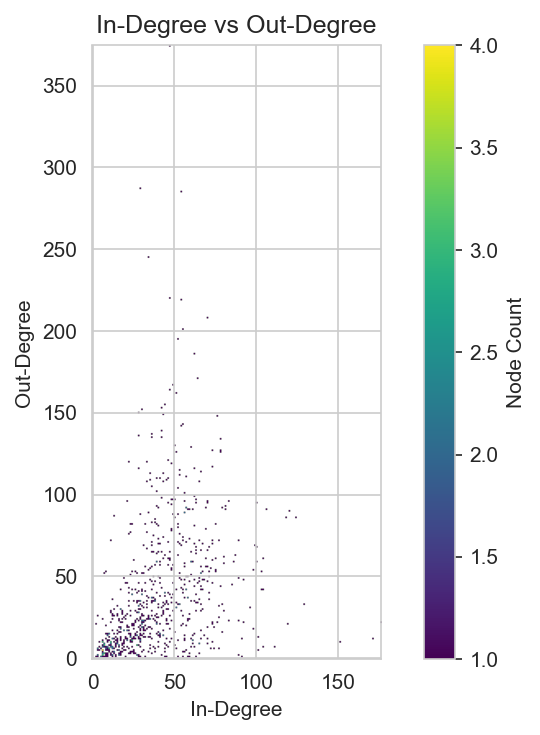

In [17]:
fig, ax = plt.subplots(figsize=(6, 5), dpi=150)

in_deg = dict(G.in_degree())
out_deg = dict(G.out_degree())
nodes = list(G.nodes())

x = np.array([in_deg[n] for n in nodes])
y = np.array([out_deg[n] for n in nodes])

bins = (np.arange(x.max() + 2) - 0.5, np.arange(y.max() + 2) - 0.5)
heatmap, xedges, yedges = np.histogram2d(x, y, bins=bins)
extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]

H = np.ma.masked_equal(heatmap.T, 0)
plt.imshow(H, extent=extent, origin='lower', cmap='viridis')
plt.xlabel("In-Degree")
plt.ylabel("Out-Degree")
plt.title("In-Degree vs Out-Degree")
plt.colorbar(label="Node Count")
plt.tight_layout()
plt.show()

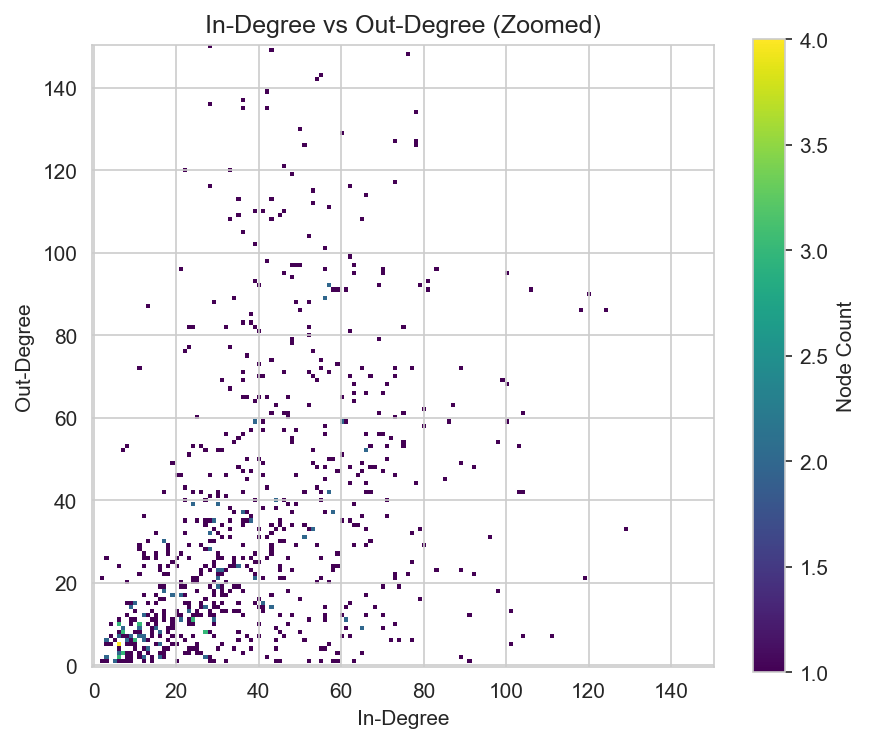

In [18]:
# Zoomed-in heatmap: Lower-left quadrant (dense region)
fig, ax = plt.subplots(figsize=(6, 5), dpi=150)

in_deg = dict(G.in_degree())
out_deg = dict(G.out_degree())
nodes = list(G.nodes())

x = np.array([in_deg[n] for n in nodes])
y = np.array([out_deg[n] for n in nodes])

zoom_max = 150
bins = (np.arange(zoom_max + 2) - 0.5, np.arange(zoom_max + 2) - 0.5)
heatmap, xedges, yedges = np.histogram2d(x, y, bins=bins)
extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]

H = np.ma.masked_equal(heatmap.T, 0)
plt.imshow(H, extent=extent, origin='lower', cmap='viridis')
plt.xlabel("In-Degree")
plt.ylabel("Out-Degree")
plt.title("In-Degree vs Out-Degree (Zoomed)")
plt.colorbar(label="Node Count")
plt.tight_layout()
plt.show()

**Interpretation:**

The plot indicates a positive relationship between in-degree and out-degree: more active users tend to both follow more people and receive more followers. This aligns with the observed reciprocity (27.6%) and the large strongly connected component (85.3%), suggesting that active users are more likely to be integrated into the network core.

The lack of extreme outliers is largely due to sampling constraints, which cap both in- and out-degree and compress the upper tail of the distribution.

The effects of the sampling constraints will be further discussed in the next section.

### 2.6 Degree Distributions:

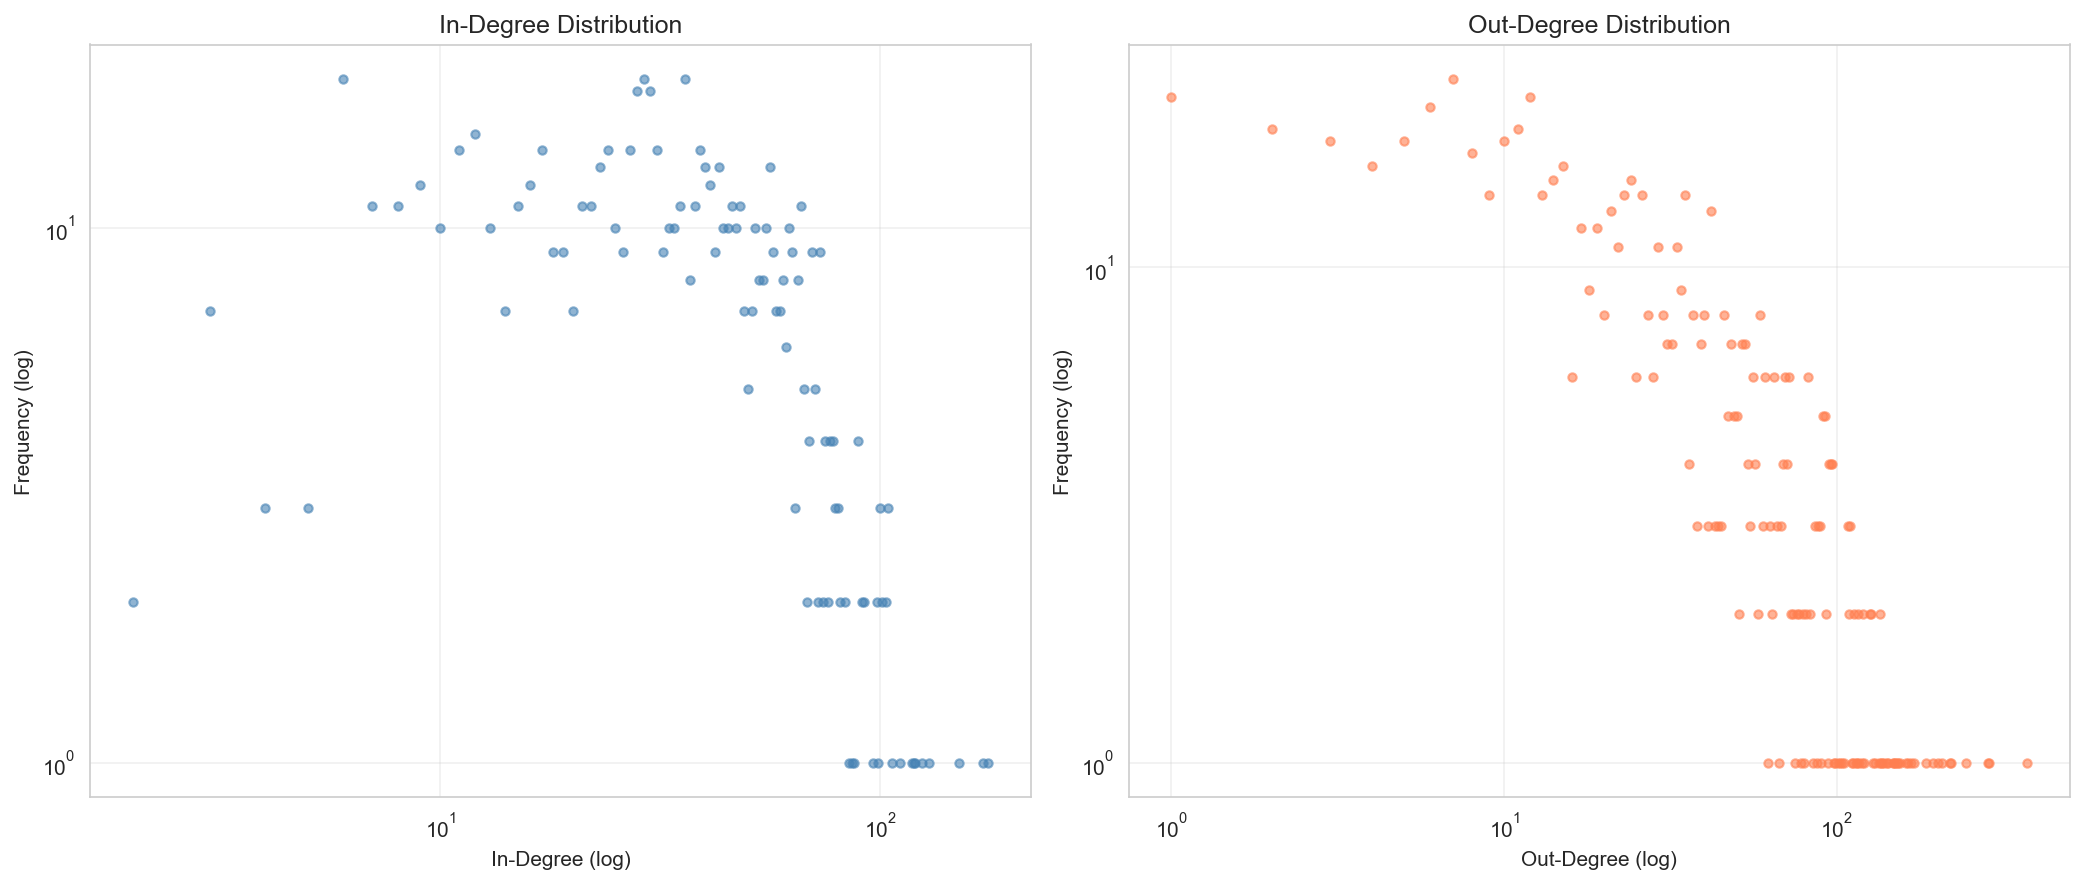

In [19]:
in_degrees_pos = [d for d in in_degrees if d > 0]
out_degrees_pos = [d for d in out_degrees if d > 0]

in_counts = Counter(in_degrees_pos)
out_counts = Counter(out_degrees_pos)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), dpi=150)

ax1.loglog(sorted(in_counts.keys()), [in_counts[k] for k in sorted(in_counts.keys())],
         'o', alpha=0.6, markersize=4, color='steelblue')
ax1.set_xlabel('In-Degree (log)')
ax1.set_ylabel('Frequency (log)')
ax1.set_title('In-Degree Distribution')
ax1.grid(True, alpha=0.3)

ax2.loglog(sorted(out_counts.keys()), [out_counts[k] for k in sorted(out_counts.keys())],
         'o', alpha=0.6, markersize=4, color='coral')
ax2.set_xlabel('Out-Degree (log)')
ax2.set_ylabel('Frequency (log)')
ax2.set_title('Out-Degree Distribution')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Interpretation:**

The log–log plots illustrate the degree distributions and clearly reflect the impact of the sampling design. Neither the in-degree nor out-degree distribution shows a clear linear trend in log–log space, indicating an absence of visible power-law behavior. This is expected given the BFS sampling from popular users combined with the 75-edge truncation, which systematically removes extreme hubs and bounds degree values.

These distributions therefore represent a bounded core of moderately active users rather than the full Letterboxd network. Both low-activity peripheral users and extreme high-degree hubs are underrepresented in this dataset.

Despite these limitations, the network remains structurally interesting: The combination of bounded degree distributions, high connectivity, and short path lengths highlights a densely interconnected core where local interaction and global reach coexist.

### 2.7 Getting the Communities:

In [20]:
# Resolution Parameter Sweep: Pick Your Poison
import pandas as pd

resolutions = np.arange(1.0, 2.6, 0.1)
results_data = []

for res in resolutions:
  communities = nx.community.louvain_communities(GUndirected, seed=42, resolution=res)
  mod = nx.community.modularity(GUndirected, communities)

  # Find largest community
  comm_sizes = [len(c) for c in communities]
  n_comms = len(communities)
  largest_comm = max(comm_sizes)

  results_data.append({
      'Resolution': f'{res:.1f}',
      '# Communities': n_comms,
      'Largest': largest_comm,
      'Modularity': f'{mod:.3f}'
  })

results_df = pd.DataFrame(results_data)

print("Resolution Parameter Trade-off:")
print("=" * 55)
print(results_df.to_string(index=False))
print("=" * 55)

Resolution Parameter Trade-off:
Resolution  # Communities  Largest Modularity
       1.0              5      444      0.371
       1.1              4      419      0.371
       1.2              5      360      0.355
       1.3              8      292      0.335
       1.4              8      278      0.334
       1.5             11      231      0.319
       1.6             10      225      0.295
       1.7             12      219      0.288
       1.8             18      210      0.275
       1.9             19      206      0.269
       2.0             23      159      0.230
       2.1             26      154      0.231
       2.2             25      147      0.206
       2.3             35      137      0.199
       2.4             38      126      0.192
       2.5             40      131      0.182


**Remark:**

The table illustrates how the Louvain resolution parameter affects the number of detected communities and the modularity value. With increasing resolution, more communities are found, while modularity steadily decreases, showing a trade-off between detailed partitions and statistical reliability.

At low resolutions (r = 1.0–1.2), only a few large communities are detected with high modularity, which may hide smaller structures. At higher resolutions (r ≥ 2.0), the network splits into many small communities and modularity falls below 0.23, suggesting less reliable partitions.

Based on this trade-off, we select r = 1.5 as the highest resolution where modularity remains above Q ≈ 0.3. This setting produces 11 communities and is used in all subsequent analyses.

In [21]:
communities = nx.community.louvain_communities(GUndirected, seed=42, resolution=1.5)
sorted_communities = sorted(communities, key=len, reverse=True)

node_to_community = {}
for i, comm in enumerate(communities):
  for node in comm:
      node_to_community[node] = i

modularity = nx.community.modularity(GUndirected, communities)

print(f"Communities: {len(communities)}")
print(f"Modularity: {modularity:.3f}")
for i, comm in enumerate(sorted_communities[:11], 1):
  print(f"  {i:2d}. {len(comm):3d} nodes ({len(comm)/G.number_of_nodes()*100:5.1f}%)")

Communities: 11
Modularity: 0.319
   1. 231 nodes ( 30.0%)
   2. 173 nodes ( 22.4%)
   3. 136 nodes ( 17.6%)
   4. 112 nodes ( 14.5%)
   5.  86 nodes ( 11.2%)
   6.  75 nodes (  9.7%)
   7.  49 nodes (  6.4%)
   8.  17 nodes (  2.2%)
   9.  12 nodes (  1.6%)
  10.  11 nodes (  1.4%)
  11.   2 nodes (  0.3%)


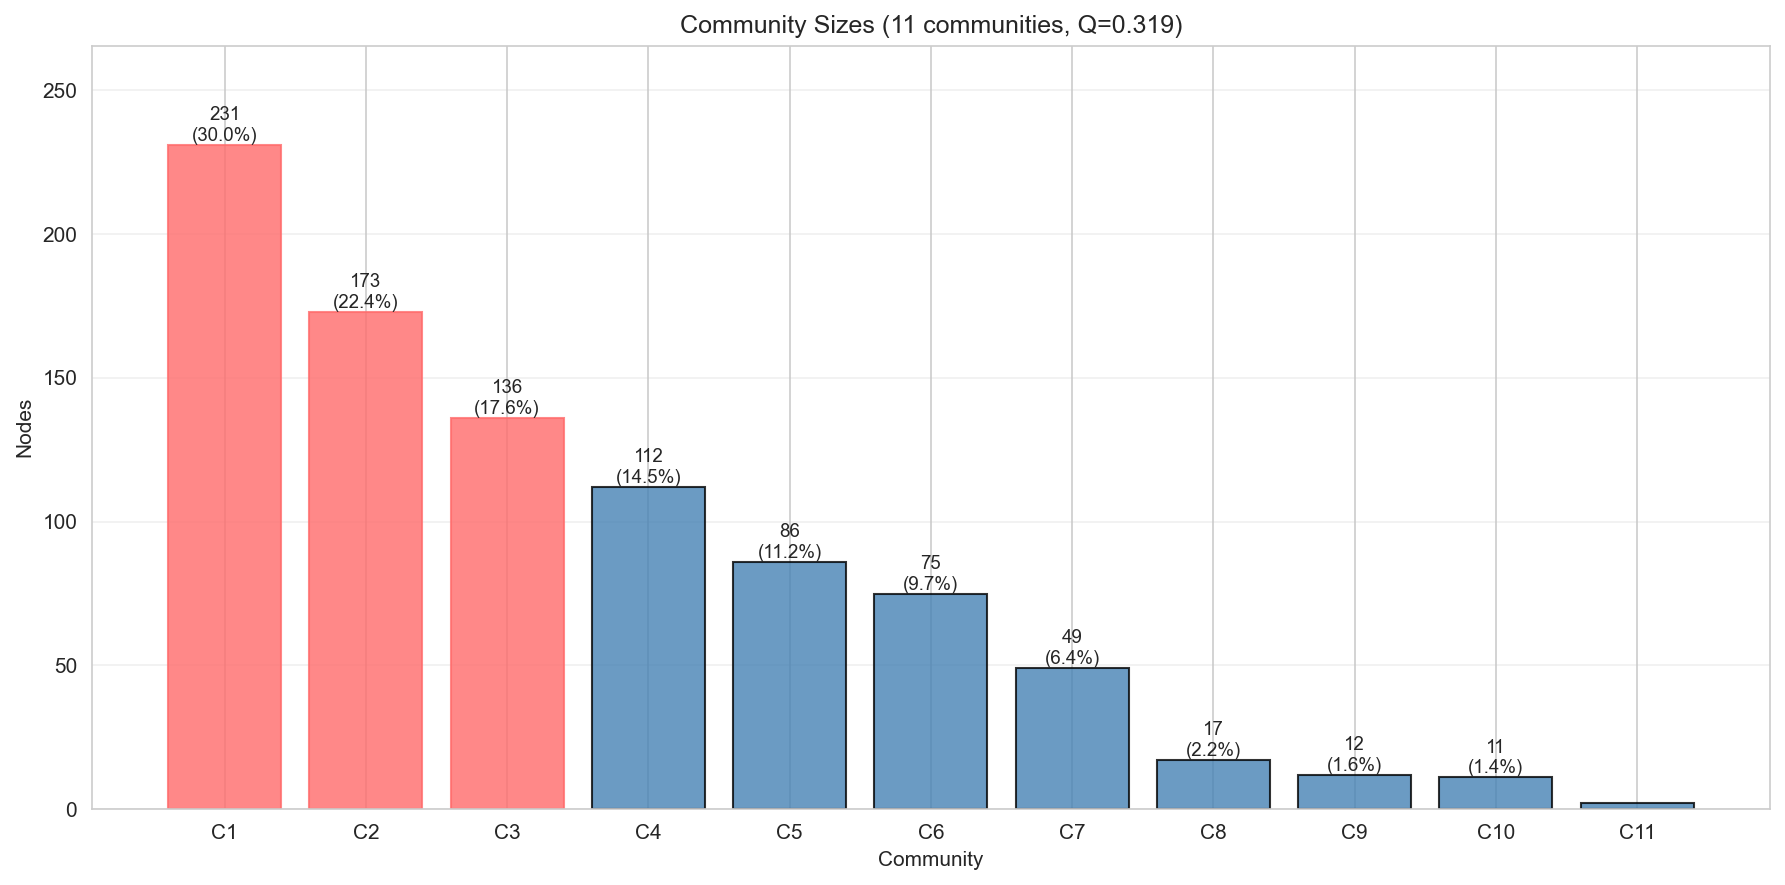

In [22]:
fig, ax = plt.subplots(figsize=(12, 6), dpi=150)

comm_sizes = [len(comm) for comm in sorted_communities]
comm_labels = [f'C{i+1}' for i in range(len(sorted_communities))]
comm_pct = [size/G.number_of_nodes()*100 for size in comm_sizes]

bars = ax.bar(comm_labels, comm_sizes, color='steelblue', alpha=0.8, edgecolor='black')

# Highlight top 3
for i in range(min(3, len(bars))):
  bars[i].set_color('#FF6B6B')

# Labels
for i, (bar, size, pct) in enumerate(zip(bars, comm_sizes, comm_pct)):
  if i < 10:
      ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
              f'{size}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Community')
ax.set_ylabel('Nodes')
ax.set_title(f'Community Sizes ({len(communities)} communities, Q={modularity:.3f})')
ax.set_ylim(0, max(comm_sizes) * 1.15)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Interpretation:**

The observed imbalance in community sizes indicates that the network is not partitioned randomly, but organized around a limited number of larger groups and several smaller ones. While this alone does not reveal the nature of these communities, it suggests that they may reflect different patterns of activity or interest within the network.

In the following sections, we therefore examine whether these structurally defined communities also differ in terms of film preferences and rating behavior.

### 2.8 General Plot of the Network:

In [24]:
degrees = dict(GUndirected.degree())
node_mass = {node: degrees[node] + 1 for node in GUndirected.nodes()}
node_radius = {node: degrees[node] * 0.5 for node in GUndirected.nodes()}

# Suppress RuntimeWarning for ForceAtlas2
with warnings.catch_warnings():
  warnings.filterwarnings('ignore', category=RuntimeWarning)
  positions = nx.forceatlas2_layout(
      GUndirected,
      max_iter=1500,
      jitter_tolerance=0.2,
      scaling_ratio=12.0,
      gravity=5.0,
      strong_gravity=True,
      linlog=True,
      node_mass=node_mass,
      node_size=node_radius,
      seed=42
  )

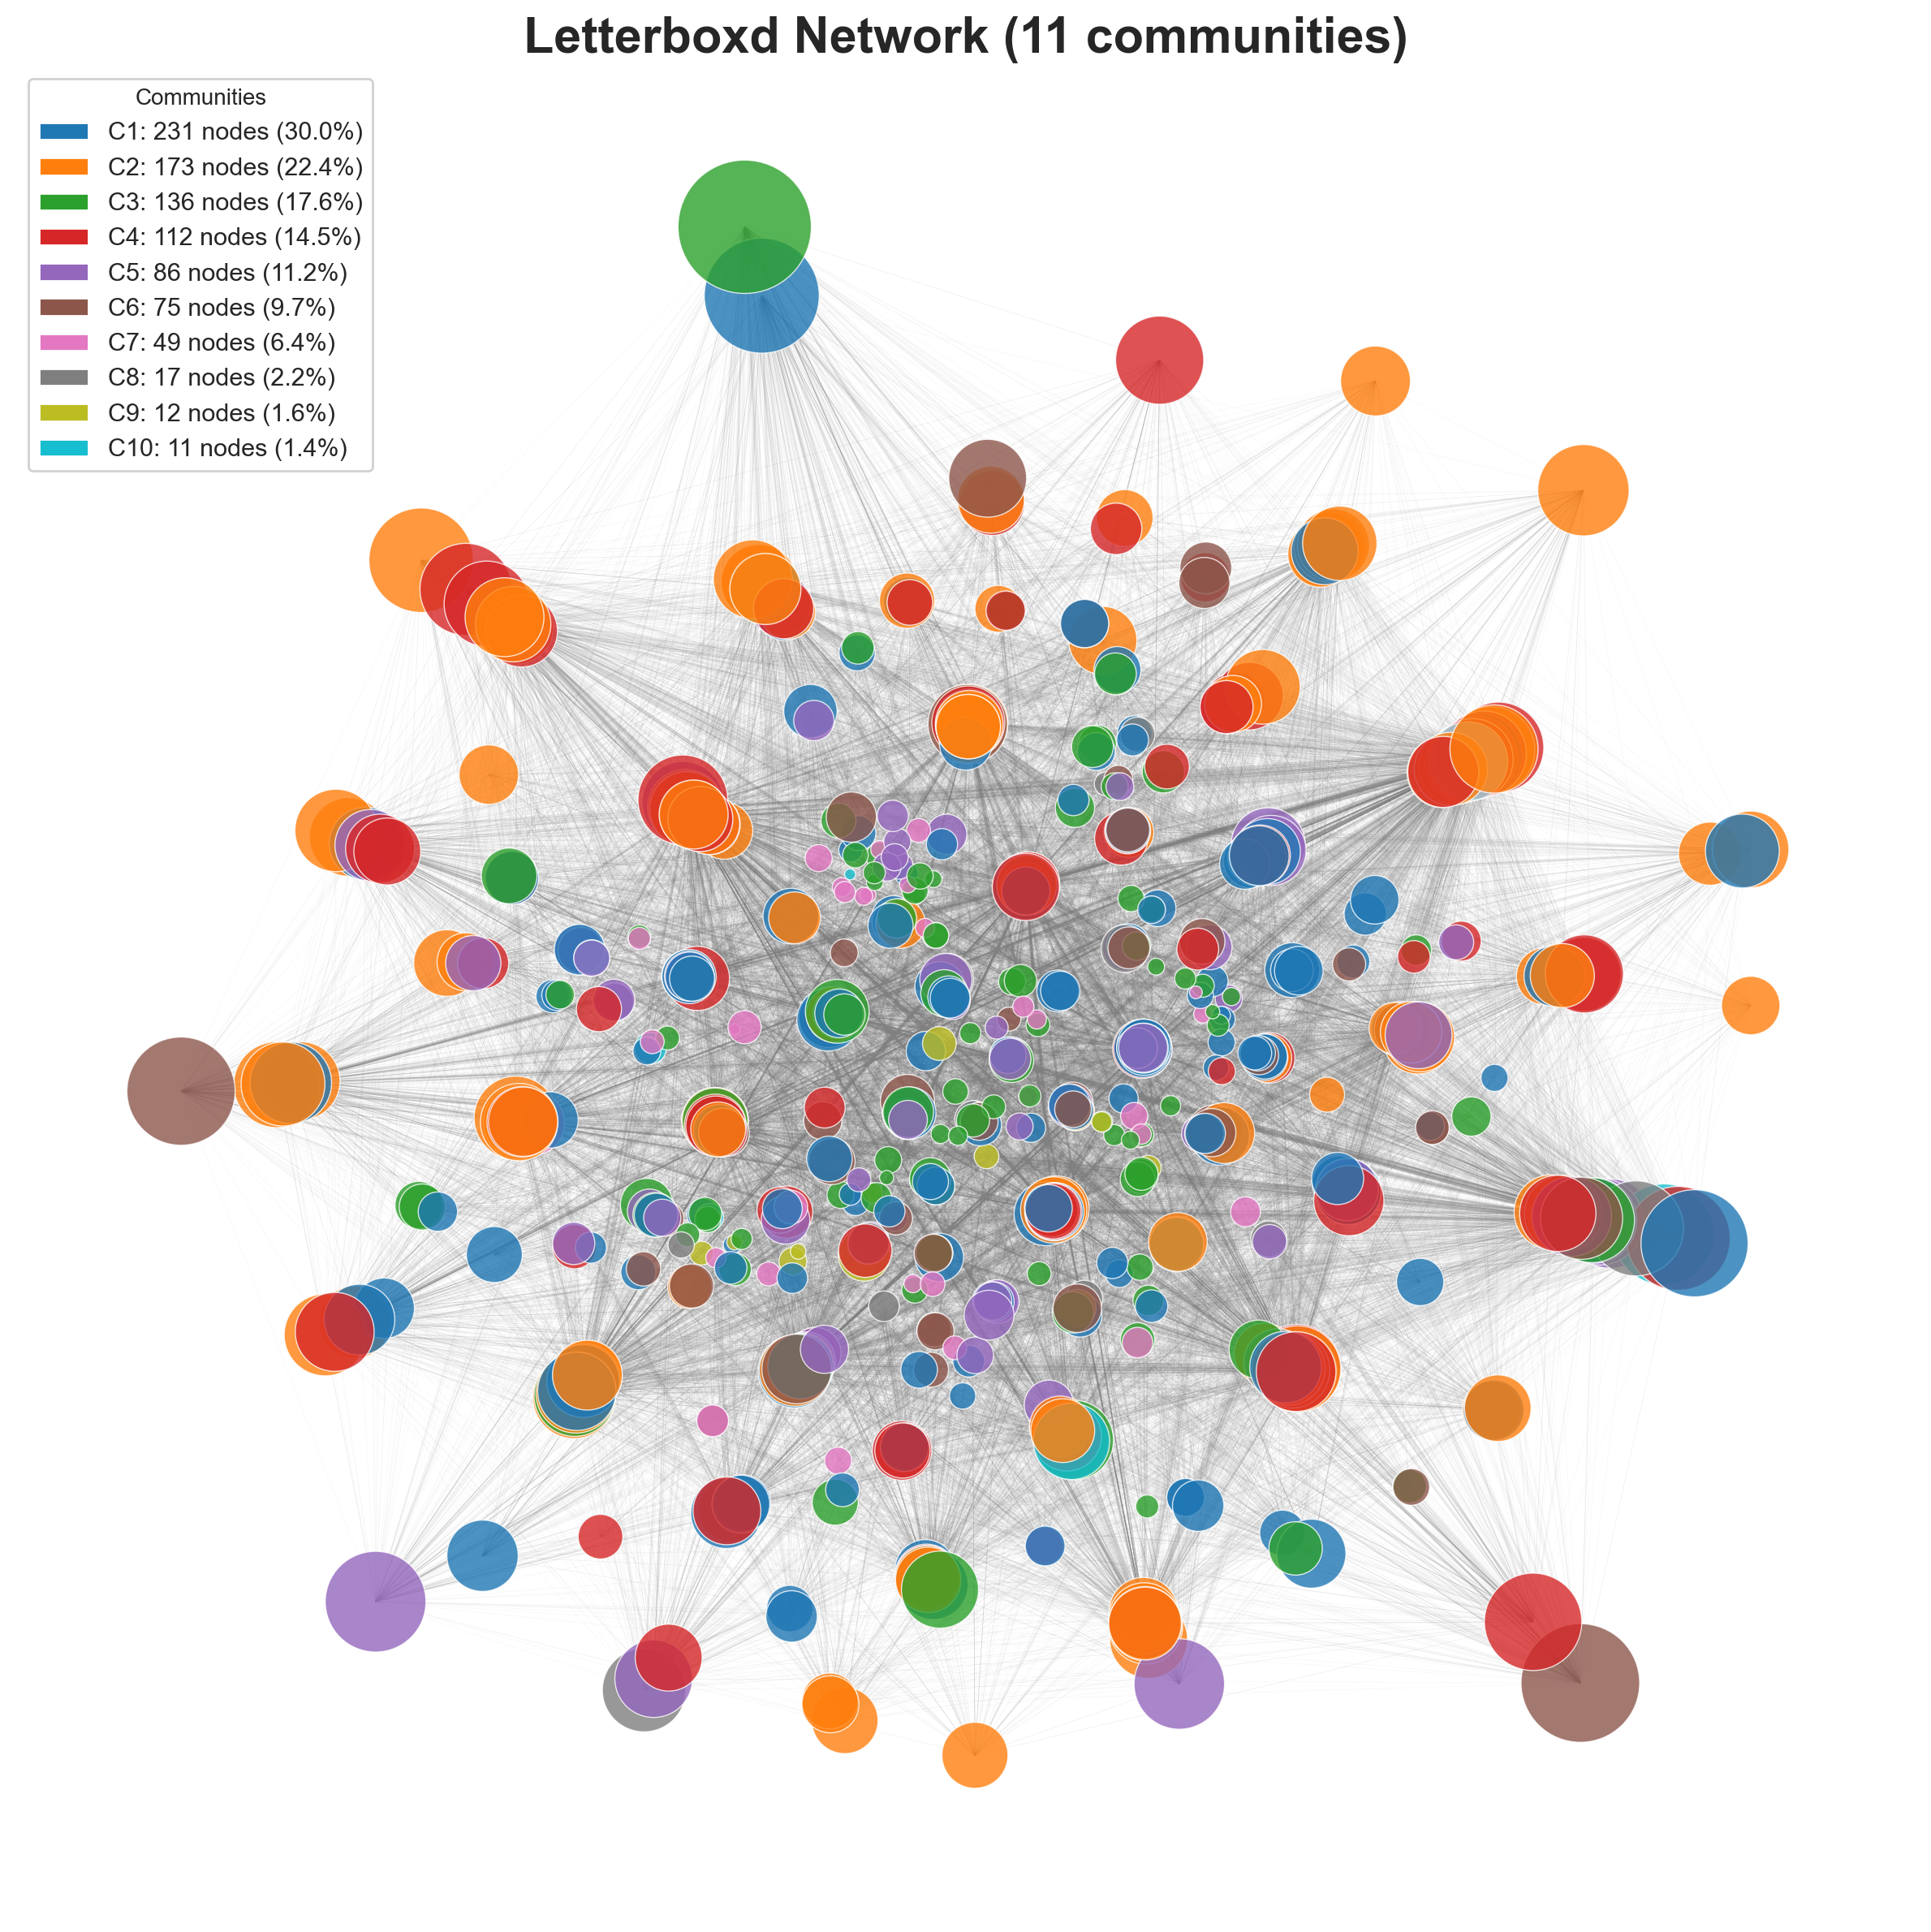

In [25]:
fig, ax = plt.subplots(figsize=(12, 12), dpi=200)

# Colors
n_communities = len(communities)
cmap_name = 'tab20' if n_communities <= 20 else 'hsv'
cmap = plt.colormaps[cmap_name].resampled(n_communities)

node_colors = []
for node in G.nodes():
    comm_idx = next(i for i, comm in enumerate(sorted_communities) if node in comm)
    node_colors.append(cmap(comm_idx))

node_sizes = [degrees[node] * 8 for node in G.nodes()]

# Draw
nx.draw_networkx_edges(G, positions, alpha=0.08, width=0.2,
                   edge_color='gray', arrows=False, ax=ax)
nx.draw_networkx_nodes(G, positions, node_size=node_sizes,
                   node_color=node_colors, alpha=0.8,
                   linewidths=0.5, edgecolors='white', ax=ax)

# Legend
legend_elements = []
for i, comm in enumerate(sorted_communities[:10]):
    size = len(comm)
    pct = size / G.number_of_nodes() * 100
    legend_elements.append(
        Patch(facecolor=cmap(i), edgecolor='white',
            label=f'C{i+1}: {size} nodes ({pct:.1f}%)')
)

ax.legend(handles=legend_elements, loc='upper left',
      fontsize=11, framealpha=0.9, title='Communities')
ax.set_title(f'Letterboxd Network ({len(communities)} communities)',
         fontsize=22, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

**Info:**

The visualization shows the network layout with nodes colored by community
assignment and sized by degree. While individual community boundaries are not
clearly separated due to the high overall connectivity, the figure illustrates
how communities are embedded within a densely interconnected core.

# Part 3: Study of the Peer Effect
## Setting up the Data
### Loading the Data

In [26]:
# Load Reviews
reviews = pd.read_csv("./reviews.csv")

# Keep only users that actually exist in the graph (just to be safe)
users_in_graph = set(G.nodes())
reviews = reviews[reviews["username_of_creator"].isin(users_in_graph)].copy()

# Keep only users with at least 5 reviews
min_reviews = 5
user_review_counts = reviews["username_of_creator"].value_counts()
valid_users = set(user_review_counts[user_review_counts >= min_reviews].index)

reviews = reviews[reviews["username_of_creator"].isin(valid_users)].copy()

print(f"Users with ≥{min_reviews} reviews and in graph: {reviews['username_of_creator'].nunique()}.")
print(f"Total reviews after filtering: {len(reviews)}.")

Users with ≥5 reviews and in graph: 709.
Total reviews after filtering: 680881.


### Setting up the Dictionaries
- User - Movies
- User - Ratings

In [27]:
user2movies = defaultdict(set)
user2ratings = defaultdict(dict)

for row in reviews.itertuples(index=False):
    u = row.username_of_creator
    m = row.moviename
    r = row.rating

    user2movies[u].add(m)

    # rating can be NaN
    if pd.notna(r):
        user2ratings[u][m] = float(r)

users_with_profiles = sorted(user2movies.keys())
print(f"Users with watch profiles: {len(users_with_profiles)}.")

Users with watch profiles: 709.


## Defining Some Helper Functions
**jaccard_watch_similarity:** Computes the Jaccard similarity between two users based on the overlap of movies they’ve both reviewed (shared vs. total unique watched).

In [28]:
def jaccard_watch_similarity(u, v):
    """Jaccard similarity of watched movies (based on review presence)."""
    Wu = user2movies.get(u, set())
    Wv = user2movies.get(v, set())

    if not Wu or not Wv:
        return np.nan

    inter = len(Wu & Wv)
    union = len(Wu | Wv)
    if union == 0:
        return np.nan
    return inter / union

**rating_similarity_pearson:** Measures how similarly two users rate the same movies using Pearson correlation, returning NaN if they share too few films or have no rating variance.

In [29]:
def rating_similarity_pearson(u, v, min_overlap=3):
    """
    Pearson correlation between rating vectors for movies
    that both users rated.
    """
    Ru = user2ratings.get(u, {})
    Rv = user2ratings.get(v, {})

    common = set(Ru.keys()) & set(Rv.keys())
    if len(common) < min_overlap:
        return np.nan

    # consistent ordering
    common = list(common)
    ru = np.array([Ru[m] for m in common], dtype=float)
    rv = np.array([Rv[m] for m in common], dtype=float)

    # handle constant vectors (zero variance -> corr undefined)
    if np.std(ru) == 0 or np.std(rv) == 0:
        return np.nan

    corr = np.corrcoef(ru, rv)[0, 1]
    return corr

### Filtering for the Eligible Users

In [30]:
rng = np.random.default_rng(42)

# Only users that are both in graph, in a community, and have profiles
eligible_users = [
    u for u in users_with_profiles
    if u in node_to_community  # has a community label
]
eligible_users = np.array(eligible_users)
print(f"Eligible users: {len(eligible_users)}.")

Eligible users: 709.


**liked_set:** Returns the set of movies a user has rated at or above a certain threshold.

In [31]:
LIKE_THRESHOLD = 4.0

def liked_set(u):
    Ru = user2ratings.get(u, {})
    return {m for m, r in Ru.items() if r >= LIKE_THRESHOLD}

**jaccard_liked:** Computes the Jaccard similarity between two users based only on the movies they “like”, returning NaN if there’s no overlap or no liked movies.

In [32]:
def jaccard_liked(u, v):
    Lu = liked_set(u)
    Lv = liked_set(v)
    if not Lu and not Lv:
        return np.nan
    inter = len(Lu & Lv)
    union = len(Lu | Lv)
    if union == 0:
        return np.nan
    return inter / union

**collect_similarity_all:** Computes all pairwise similarity scores (watch-history, ratings, and liked-movies) for eligible user pairs, splitting them into within- vs between-community distributions.

In [33]:
def collect_similarity(n_users_sample=None, rng=None):
    """
    Compute similarity metrics using user-level sampling instead of all pairs.

    For each sampled user u, we:
      - pick ONE random within-community partner v_same
      - pick ONE random between-community partner v_diff
      - compute similarities sim(u, v_same) and sim(u, v_diff)

    These go into the within_* and between_* arrays respectively.

    Returns
    -------
    within_watch, between_watch,
    within_rating, between_rating,
    within_liked, between_liked : np.ndarray
    """
    if rng is None:
        rng = np.random.default_rng(42)

    n_users = len(eligible_users)
    indices = np.arange(n_users)

    # How many users to sample?
    if n_users_sample is None or n_users_sample > n_users:
        sampled_idx = indices  # use all eligible users
    else:
        sampled_idx = rng.choice(indices, size=n_users_sample, replace=False)

    # Precompute community labels for all eligible users
    comms_all = np.array([node_to_community[u] for u in eligible_users])

    within_watch = []
    between_watch = []
    within_rating = []
    between_rating = []
    within_liked = []
    between_liked = []

    for k, idx in enumerate(sampled_idx, start=1):
        u = eligible_users[idx]
        comm_u = comms_all[idx]

        # candidate partners among ALL eligible users
        same_idx = indices[(comms_all == comm_u) & (indices != idx)]
        diff_idx = indices[comms_all != comm_u]

        # skip users without both types of partners
        if len(same_idx) == 0 or len(diff_idx) == 0:
            continue

        j_same = rng.choice(same_idx)
        j_diff = rng.choice(diff_idx)

        v_same = eligible_users[j_same]
        v_diff = eligible_users[j_diff]

        # compute similarities
        w_within = jaccard_watch_similarity(u, v_same)
        w_between = jaccard_watch_similarity(u, v_diff)

        r_within = rating_similarity_pearson(u, v_same)
        r_between = rating_similarity_pearson(u, v_diff)

        l_within = jaccard_liked(u, v_same)
        l_between = jaccard_liked(u, v_diff)

        # WATCH
        if not np.isnan(w_within):
            within_watch.append(w_within)
        if not np.isnan(w_between):
            between_watch.append(w_between)

        # RATING
        if not np.isnan(r_within):
            within_rating.append(r_within)
        if not np.isnan(r_between):
            between_rating.append(r_between)

        # LIKED
        if not np.isnan(l_within):
            within_liked.append(l_within)
        if not np.isnan(l_between):
            between_liked.append(l_between)

        # (optional) simple progress logging
        if k % 100 == 0:
            print(f"{k}/{len(sampled_idx)} users processed.")

    print("Done (user-level sampling).")
    print(f"Within-community watch sims:   {len(within_watch)}")
    print(f"Between-community watch sims:  {len(between_watch)}")
    print(f"Within-community rating sims:  {len(within_rating)}")
    print(f"Between-community rating sims: {len(between_rating)}")
    print(f"Within-community liked sims:   {len(within_liked)}")
    print(f"Between-community liked sims:  {len(between_liked)}")

    return (
        np.array(within_watch, dtype=float),
        np.array(between_watch, dtype=float),
        np.array(within_rating, dtype=float),
        np.array(between_rating, dtype=float),
        np.array(within_liked, dtype=float),
        np.array(between_liked, dtype=float),
    )


# Call stays the same (uses all eligible users as sampling units by default):
within_watch, between_watch, within_rating, between_rating, within_liked, between_liked = collect_similarity()

100/709 users processed.
200/709 users processed.
300/709 users processed.
400/709 users processed.
500/709 users processed.
600/709 users processed.
700/709 users processed.
Done (user-level sampling).
Within-community watch sims:   708
Between-community watch sims:  708
Within-community rating sims:  552
Between-community rating sims: 562
Within-community liked sims:   706
Between-community liked sims:  707


## Results
**summarize:** Prints a compact summary of within- vs between-community similarity distributions, including sample sizes plus mean and median values for each.

In [34]:
def summarize(name, within, between):
    print(f"\n=== {name} similarity ===")
    print(f"Within-community  n={len(within):5d}, mean={np.nanmean(within):.4f}, median={np.nanmedian(within):.4f}.")
    print(f"Between-community n={len(between):5d}, mean={np.nanmean(between):.4f}, median={np.nanmedian(between):.4f}.")

summarize("Watch-history (Jaccard)", within_watch, between_watch)
summarize("Rating (Pearson)",       within_rating, between_rating)
summarize("Liked-movies (Jaccard)", within_liked, between_liked)


=== Watch-history (Jaccard) similarity ===
Within-community  n=  708, mean=0.0567, median=0.0393.
Between-community n=  708, mean=0.0488, median=0.0341.

=== Rating (Pearson) similarity ===
Within-community  n=  552, mean=0.3810, median=0.4019.
Between-community n=  562, mean=0.3330, median=0.3602.

=== Liked-movies (Jaccard) similarity ===
Within-community  n=  706, mean=0.0515, median=0.0352.
Between-community n=  707, mean=0.0448, median=0.0294.


**compare_distributions:** Compares within- vs between-community similarity using Mann–Whitney U and reports the mean difference (Δ) plus a one-sided p-value for “within > between.”

In [35]:
def compare_distributions(name, within, between):
    # Drop NaNs if any slipped through
    within = within[~np.isnan(within)]
    between = between[~np.isnan(between)]

    stat, p = mannwhitneyu(within, between, alternative="greater")
    delta = np.mean(within) - np.mean(between)

    print(f"\n=== {name} ===")
    print(f"Effect size Δ = E[within] - E[between] = {delta:.4f}")
    print(f"Mann–Whitney U = {stat:.0f}, p-value (within > between) = {p:.3e}")

compare_distributions("Watch-history (Jaccard)", within_watch, between_watch)
compare_distributions("Rating similarity (Pearson)", within_rating, between_rating)
compare_distributions("Liked-movies (Jaccard)", within_liked, between_liked)


=== Watch-history (Jaccard) ===
Effect size Δ = E[within] - E[between] = 0.0079
Mann–Whitney U = 271282, p-value (within > between) = 3.637e-03

=== Rating similarity (Pearson) ===
Effect size Δ = E[within] - E[between] = 0.0479
Mann–Whitney U = 173366, p-value (within > between) = 3.372e-04

=== Liked-movies (Jaccard) ===
Effect size Δ = E[within] - E[between] = 0.0067
Mann–Whitney U = 264360, p-value (within > between) = 2.680e-02


**cohens_d:** Computes Cohen’s d effect size as the standardized mean difference between within- and between-community similarity scores using a pooled standard deviation.

In [36]:
def cohens_d(within, between):
    within = within[~np.isnan(within)]
    between = between[~np.isnan(between)]

    m1, m2 = np.mean(within), np.mean(between)
    s1, s2 = np.std(within, ddof=1), np.std(between, ddof=1)

    # pooled standard deviation
    n1, n2 = len(within), len(between)
    s_pooled = np.sqrt(((n1-1)*s1**2 + (n2-1)*s2**2) / (n1 + n2 - 2))

    return (m1 - m2) / s_pooled

print(f"Cohen's d (watch):   {cohens_d(within_watch, between_watch):.4f}.")
print(f"Cohen's d (ratings): {cohens_d(within_rating, between_rating):.4f}.")
print(f"Cohen's d (liked):   {cohens_d(within_liked, between_liked):.4f}.")

Cohen's d (watch):   0.1578.
Cohen's d (ratings): 0.1770.
Cohen's d (liked):   0.1340.


**plot_violin:** Draws side-by-side violin plots for within- vs between-community similarity scores, showing their distributions and mean values for visual comparison.

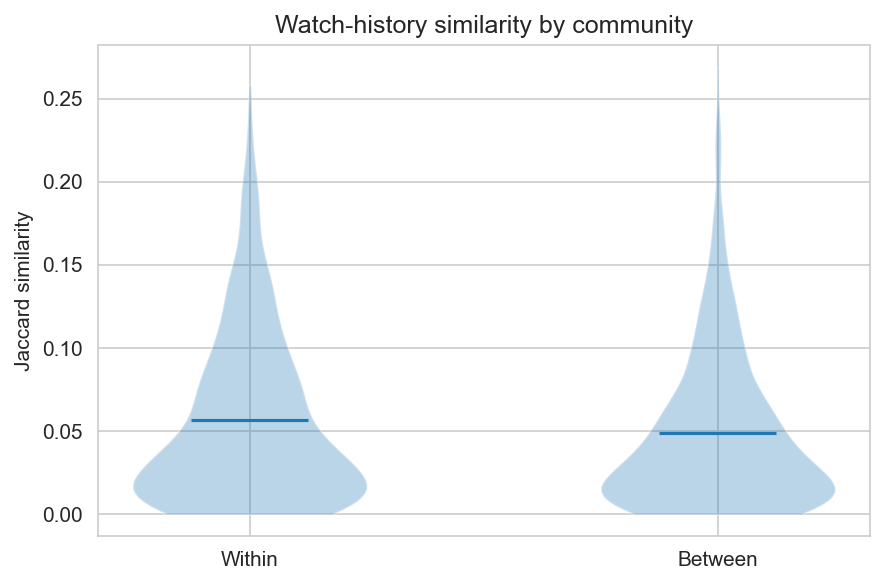

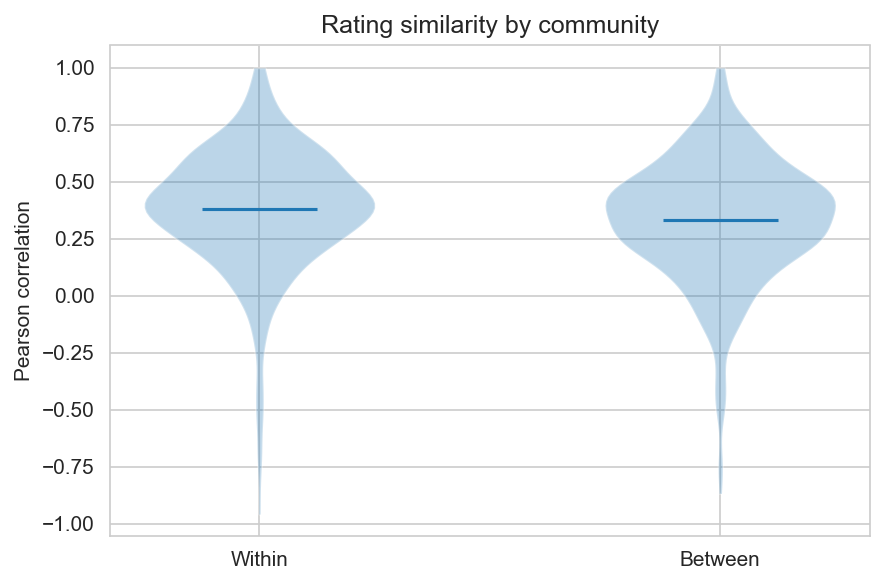

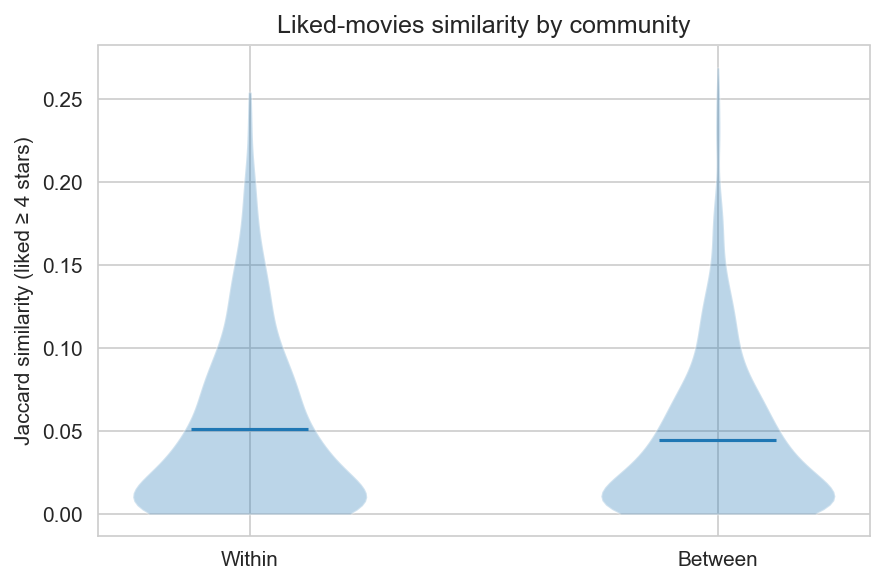

In [37]:
def plot_violin(within, between, title, ylabel):
    data = [
        within[~np.isnan(within)],
        between[~np.isnan(between)]
    ]

    fig, ax = plt.subplots(figsize=(6, 4), dpi=150)
    ax.violinplot(data, showmeans=True, showextrema=False)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(["Within", "Between"])
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

plot_violin(within_watch, between_watch,
            "Watch-history similarity by community",
            "Jaccard similarity")

plot_violin(within_rating, between_rating,
            "Rating similarity by community",
            "Pearson correlation")

plot_violin(within_liked, between_liked,
            "Liked-movies similarity by community",
            "Jaccard similarity (liked ≥ 4 stars)")

## Interpretation
Although, we discuss these results in the research paper too. We include a short interpretation for these results here too.
###
Across **all** three similarity measures, pairs of users within the same community are more similar than pairs between communities.
#### Watch-history Jaccard
  - Within: 0.0494
  - Between: 0.0436
  - $\Delta \approx 0.0058 \;\Rightarrow\; \sim 13\%$ higher within communities.

#### Rating similarity (Pearson)
  - Within: 0.3639
  - Between: 0.3274
  - $\Delta \approx 0.0365 \;\Rightarrow\; \sim 11\%$ higher within communities.

#### Liked-movies Jaccard
  - Within: 0.0435
  - Between: 0.0391
  - $\Delta \approx 0.0044 \;\Rightarrow\; \sim 11\%$ higher within communities.

### Cohen's d

Cohen’s $d$ values are:

- Watch-history Jaccard: 0.14
- Rating similarity: 0.13
- Liked-movies Jaccard: 0.10

Using the recommended rule of thumb, these values mean a small effect size.

### p-Value

The one-sided Mann–Whitney p-values (on the order of $10^{-31}$ to $10^{-119}$) indicate that
> Given the p-values, it is very unlikely that within- and between-community similarities come from the same distribution.

This shows that the effect size is small, but we can state with high-confidence, that it is real.





# Part 4: Sentiment Analysis

### Calculating the sentiment

In [38]:
reviews = pd.read_csv("reviews.csv")

def tokenize(text: str):
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", "", text)
    return text.split()

def download_labmt_wordlist():
    labmt_df = pd.read_csv('Hedonometer.csv')

    labmt = {
        row["Word"].lower(): float(row["Happiness Score"])
        for _, row in labmt_df.iterrows()
    }
    return labmt

labmt = download_labmt_wordlist()

def calculate_sentiment(
    tokens: Iterable[str],
    labmt: Dict[str, float],
    stop_window: Tuple[float, float] = (4.0, 6.0),
    return_detail: bool = False,
) -> Union[Optional[float], Tuple[Optional[float], int, int]]:

    # Count only words that exist in LabMT
    freq = Counter(t for t in tokens if t in labmt)
    if not freq:
        return (None, 0, 0) if return_detail else None

    low, high = stop_window
    kept: Dict[str, int] = {}
    removed = 0

    for word, count in freq.items():
        score = labmt[word]
        if low <= score <= high:
            removed += count
        else:
            kept[word] = count

    total = sum(kept.values())
    if total == 0:
        return (None, 0, removed) if return_detail else None

    score = sum(labmt[word] * count for word, count in kept.items()) / total
    score = round(score, 2)
    return (score, total, removed) if return_detail else score


def compute_sentiment(text: str):
    if not isinstance(text, str):
        return None

    tokens = tokenize(text)
    return calculate_sentiment(tokens, labmt)

reviews["sentiment_score"] = reviews["review_content"].apply(compute_sentiment)
reviews.to_csv('reviews_with_sentiment.csv', index=False)


### Finding the average sentiment score for each movie

In [39]:
def compute_movie_sentiment_correlation(
    reviews_path: str,
    movies_path: str,
    output_path: str = "movie_sentiment_and_rating.csv"
):
    """
    Parameters
    ----------
    reviews_path : str
        Path to the reviews_with_sentiment.csv file.
    movies_path : str
        Path to the movies.csv file.
    output_path : str
        Where to save the merged dataset.
    """
    # Load and clean reviews
    reviews = pd.read_csv(reviews_path)
    reviews_clean = reviews.dropna(subset=["rating", "sentiment_score"])

    # Calculate average sentiment per movie
    avg_sentiment = (
        reviews_clean.groupby("moviename")
            .agg(
                avg_sentiment=("sentiment_score", "mean"),
                n_reviews=("sentiment_score", "size")
            )
            .reset_index()
    )
    avg_sentiment["avg_sentiment"] = avg_sentiment["avg_sentiment"].round(2)

    movies = pd.read_csv(movies_path)
    movies["genre"] = movies["genres"].str.split("|").str[0].str.strip()

    movie_data = movies[["movie_name", "rating", "genre"]].rename(
        columns={"movie_name": "moviename"}
    )

    # Merge sentiment with movies
    merged = avg_sentiment.merge(movie_data, on="moviename", how="inner")

    # Drop missing values
    clean_dataset = merged.dropna(subset=["rating", "avg_sentiment"])

    clean_dataset.to_csv(output_path, index=False)

    correlation = clean_dataset["avg_sentiment"].corr(
        clean_dataset["rating"], method="pearson"
    )

    print("Pearson correlation:", round(correlation, 3))
    return clean_dataset,correlation

clean_dataset, correlation = compute_movie_sentiment_correlation(
   reviews_path="reviews_with_sentiment.csv",
    movies_path="movies.csv",
    output_path="movie_sentiment_and_rating.csv"
)

Pearson correlation: 0.262


**Interpretation**
 - Pearson correlation coefficient of **0.262** showing a positive, yet rather weak correlation
 - Movies with higher sentiment scores tend to have slightly higher user ratings
 - However the correlation is weak, showing that written language does not strongly reflect the given rating


#### Scatter plot for movie ratings in comparison to their sentiment score

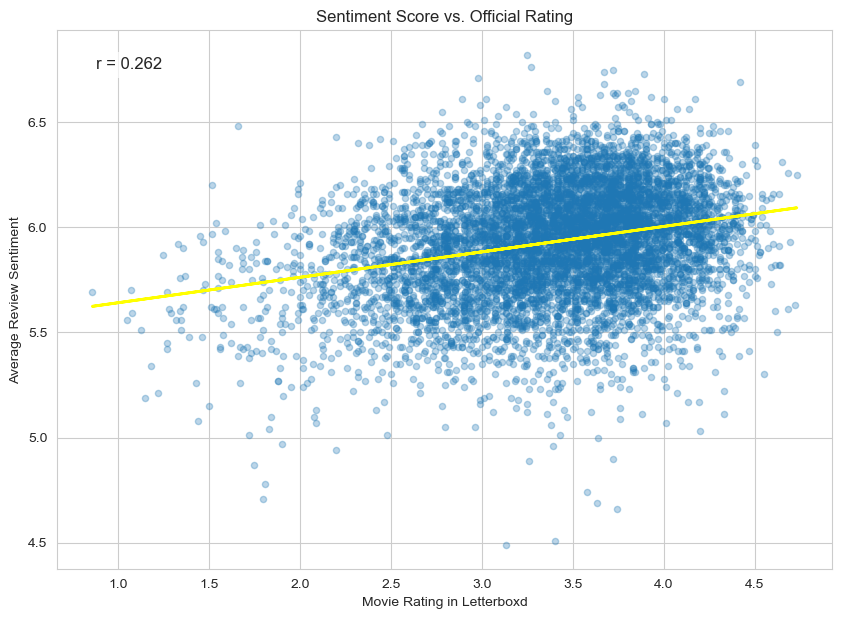

In [40]:
x = clean_dataset["rating"]
y = clean_dataset["avg_sentiment"]

if correlation is None:
    correlation = y.corr(x, method="pearson")

plt.figure(figsize=(10, 7))
plt.scatter(x, y, alpha=0.3, s=20)

# Trend line
m, b = np.polyfit(x, y, 1)
plt.plot(x, m * x + b, linewidth=2, label="Trend line", color="yellow")

plt.text(
    0.05, 0.95,
    f"r = {correlation:.3f}",
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment="top",
    bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
)

plt.xlabel("Movie Rating in Letterboxd")
plt.ylabel("Average Review Sentiment")
plt.title("Sentiment Score vs. Official Rating")
plt.grid(True)
plt.show()


**Interpretation**
- The trend line goes upward visualizing that movies with higher ratings tend to also have slightly higher sentiment scores
- The points show high spread around the line, which shows that movies with similar ratings have quite different sentiment scores

### Finding the sentiment score for different genres

In [41]:
genre_sentiment = (
      clean_dataset.groupby("genre")
                 .agg(
                      avg_sentiment=("avg_sentiment", "mean"),
                  )
                  .reset_index()
 )

print("genres", genre_sentiment.round(3))

genres               genre  avg_sentiment
0            Action          5.889
1         Adventure          5.988
2         Animation          6.047
3            Comedy          6.065
4             Crime          5.849
5       Documentary          5.969
6             Drama          5.953
7            Family          6.095
8           Fantasy          5.981
9           History          5.936
10           Horror          5.714
11            Music          6.111
12          Mystery          5.822
13          Romance          6.063
14  Science Fiction          5.890
15         TV Movie          5.900
16         Thriller          5.795
17              War          5.840
18          Western          5.904


**Interpretation**
- All genres cluster around a moderately positive average sentiment (≈ 5.8–6.1)
- This means that users generally write reviews using mildly positive language, regardless of movie genre
- The genres with the highest sentiment are Family, Comedy, Music and Romance, which makes sense since these genres naturally contain feel-good content with a more uplifting theme.
- The genres with the lowest sentiment are Horror, Thriller and Crime, which alignes with their darker or more intense content

### Plot for comparing users' review sentiment score vs the rating they gave

Spearman correlation: 0.128


2025-12-09 14:54:16,698 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-12-09 14:54:16,859 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


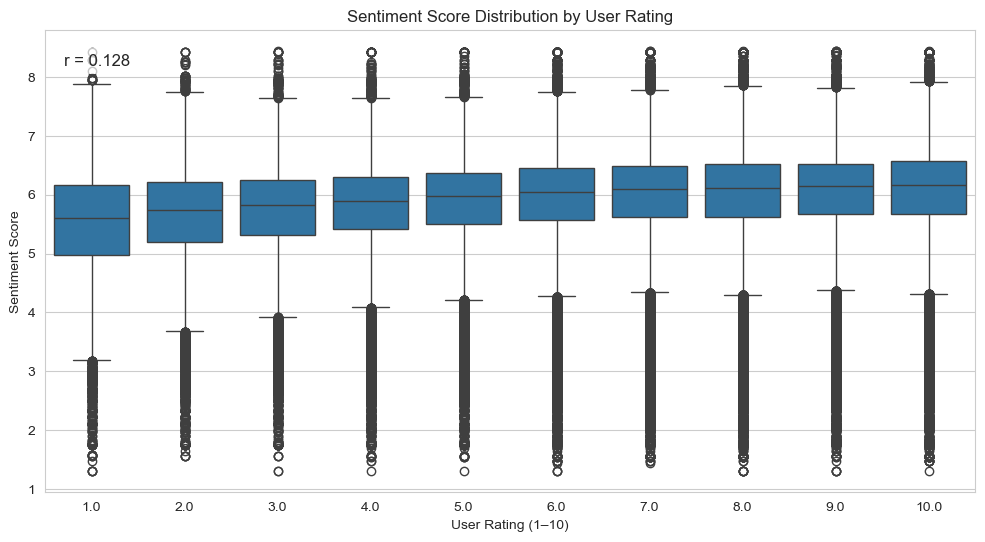

In [42]:
# Calculating the Spearman correlation coefficient
corr_spearman = reviews["rating"].corr(reviews["sentiment_score"], method="spearman")
print("Spearman correlation:", corr_spearman.__round__(3))

# plot the sentiment score vs review the user gave
plt.figure(figsize=(12,6))
sns.boxplot(x=reviews["rating"], y=reviews["sentiment_score"])

plt.text(
    0.02, 0.95,
    f"r = {corr_spearman:.3f}",
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment="top",
    bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
)
plt.xlabel("User Rating (1–10)")
plt.ylabel("Sentiment Score")
plt.title("Sentiment Score Distribution by User Rating")
plt.show()

**Intepretation**
- The Spearman correlation coefficient between user rating and sentiment score is 0.128, showing a very weak positive correlation
- This suggests that users who assign higher ratings tend to write slightly more positive reviews, but the effect is minimal, showing that the emotional tone of the review test is only loosely related to the users rating.
- The interquartile range (middle 50%) is very similar across all ratings (IQR ~ 5.3 to 6.3), which shows that most reviews cluster around a neutral or slightly positive tone


# Part 5: Word clouds for each community

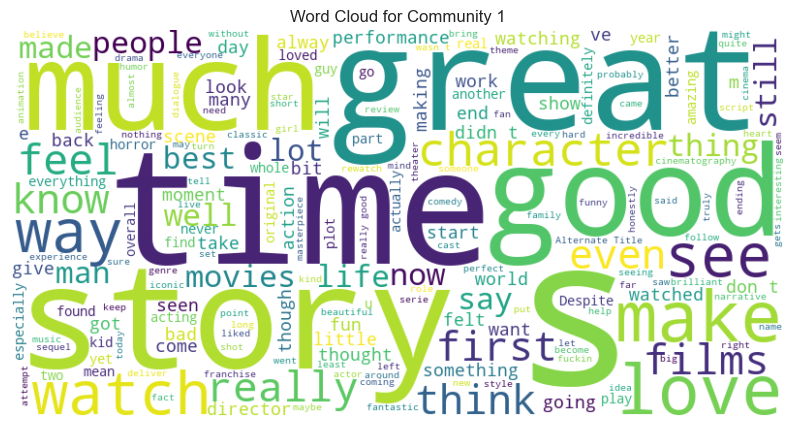

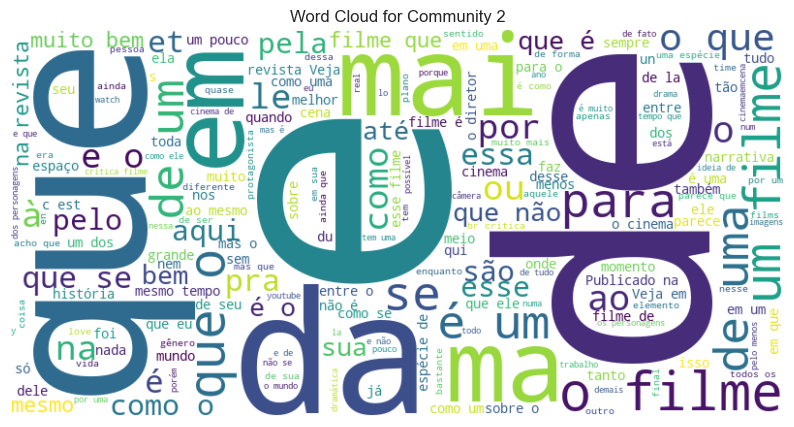

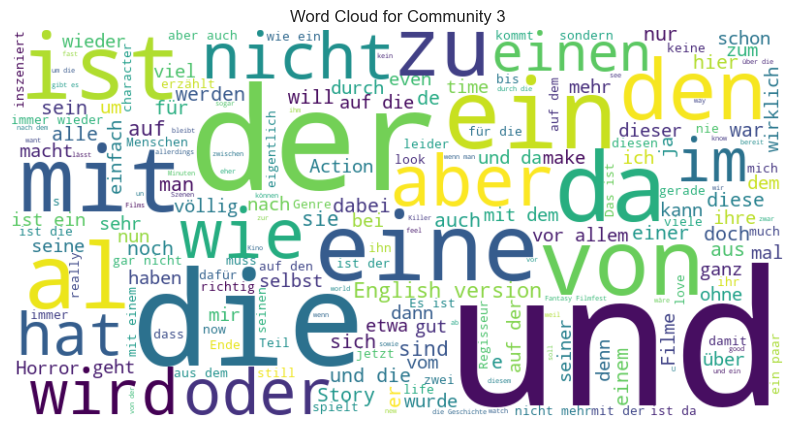

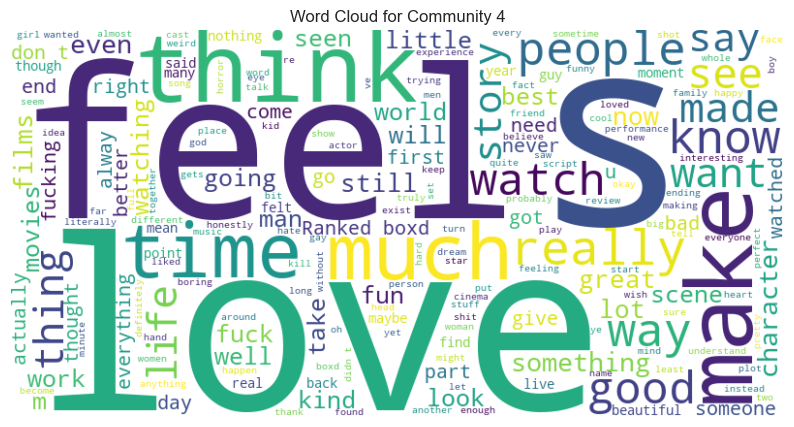

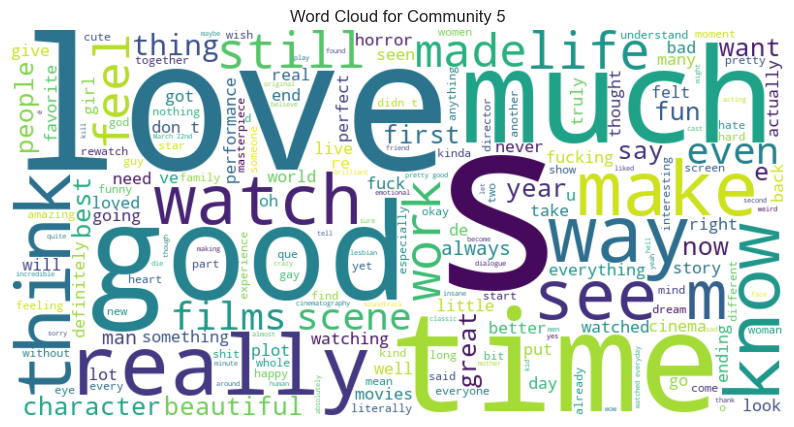

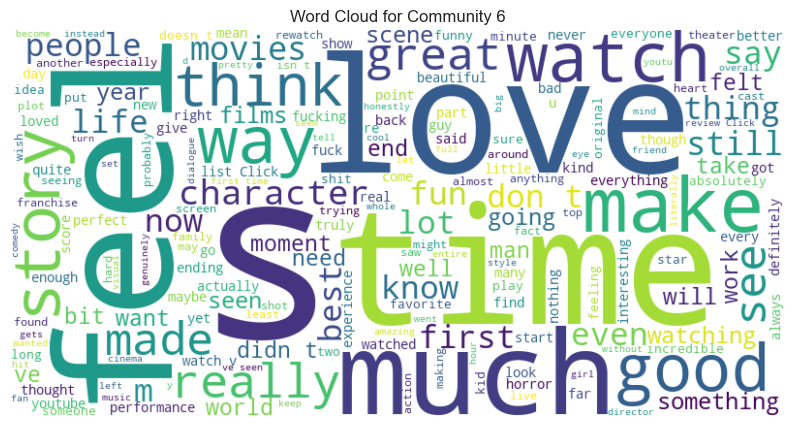

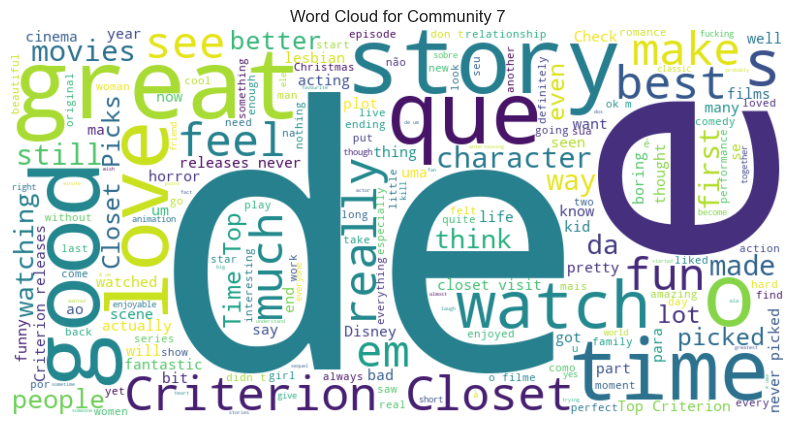

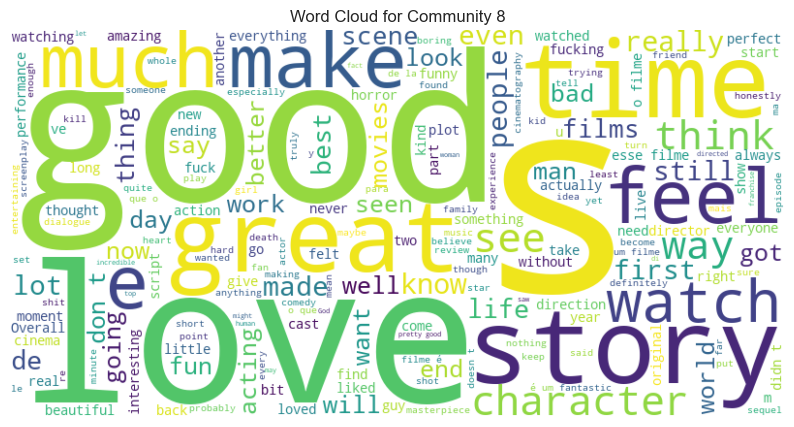

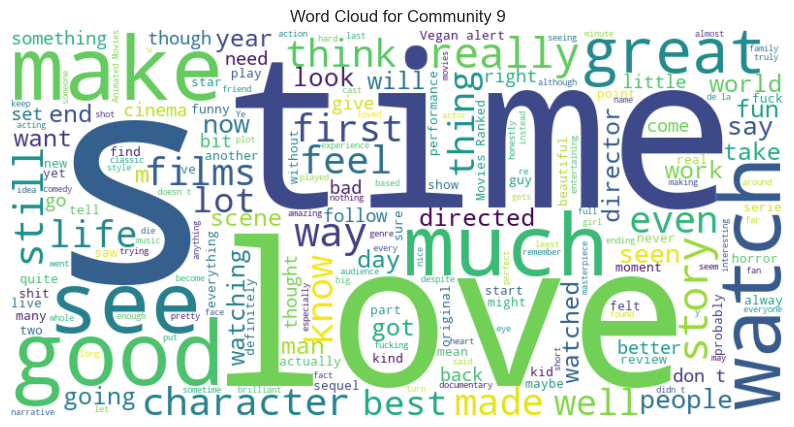

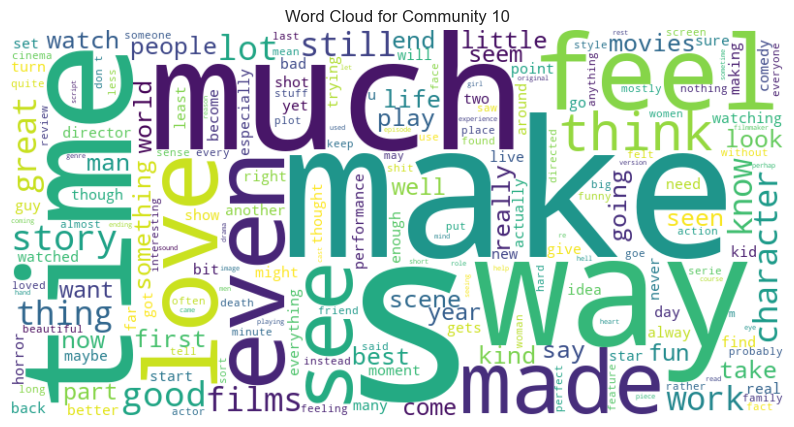

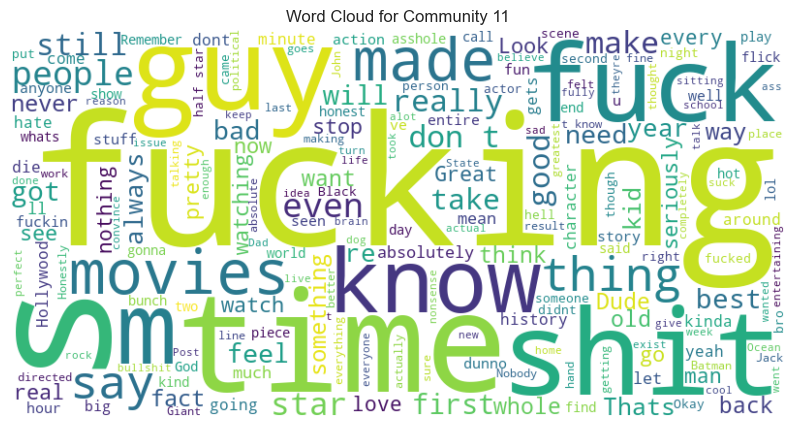

In [44]:
def generate_word_clouds(
        user_communities_path: str,
        reviews_path: str,
):
    user_communities = pd.read_csv(user_communities_path)
    reviews = pd.read_csv(reviews_path)

    reviews = reviews.rename(columns={"username_of_creator": "username"})
    df = reviews.merge(user_communities, on="username", how="inner")

    community_text = (
        df.groupby("community_id")["review_content"]
          .apply(lambda x: " ".join(x.dropna().astype(str)))
    )

    stopwords = STOPWORDS.union({"movie", "film", "one", "like", "the"})

    for comm, text in community_text.items():
        wc = WordCloud(
            width=800, height=400,
            background_color="white",
            stopwords=stopwords
        ).generate(text)

        plt.figure(figsize=(10,6))
        plt.imshow(wc, interpolation="bilinear")
        plt.axis("off")
        plt.title(f"Word Cloud for Community {comm}")
        plt.show()


generate_word_clouds(
    user_communities_path="./user_community_mapping.csv",
    reviews_path="./reviews_with_sentiment.csv"
)


**Interpretation**
- In total there are 11 word clouds for 11 different communities
- From the word clouds you can see how different communities divide
- Interestingly we can see that two word clouds are language based - german and spanish
- As well as the Community 11 shows rather a harsh and negative tone with words, whereas Community 8 shows words like "love", "great", "good" which all represent a happier tone